In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.preprocessing import OneHotEncoder
from  scipy import stats
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler,PowerTransformer
from sklearn.cluster import KMeans,DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
import seaborn as sns

### Loading the file 

In [5]:
df=pd.read_csv('CC.csv').drop('CUST_ID',axis=1)

### EDA

In [3]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT

df.isnull().sum()

In [6]:
columns=df.columns

In [23]:
columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='object')

### function for datafrme making

In [7]:
def Dataframe(x,col):
    df=pd.DataFrame(data=x,columns=col)
    return df
    

# preprocessing 

### remove the values which negative and zero

In [8]:
df= df[df['TENURE'] > 0]
df=df[df['CREDIT_LIMIT'] > 0]

### impute the missing of data by median 

In [10]:
imputer=SimpleImputer(strategy='median')
df2=imputer.fit_transform(df)

In [11]:
df1=df2.copy()

In [12]:
df1=Dataframe(df1,columns)

In [13]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


### reduce the dimension into two to see the data

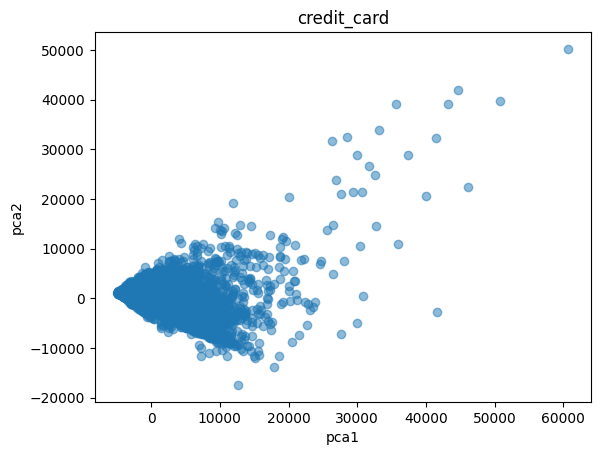

In [35]:
pca=PCA(n_components=2)
x_pca=pca.fit_transform(df1)
plt.scatter(x_pca[:,0],x_pca[:,1],alpha=0.5)
plt.xlabel('pca1')
plt.ylabel('pca2')
plt.title('credit_card')
plt.show()


### function histogram name indicate use to show the distibution of the data

In [15]:
def histogram(df):
    for col in df.columns:
        plt.figure(figsize=(12,6))
        sns.histplot(data=df,x=col)
        plt.title(f'{col} and skewness is {df[col].skew()}')
        plt.show()

### function cliping is used the push the data which 1% and 99% come to that between 

In [16]:
def cliping(df1,clip_col):
    target_data = df1.iloc[:, clip_col]
    df1.iloc[:, clip_col] = target_data.clip(lower=target_data.quantile(0.01), 
                                         upper=target_data.quantile(0.99), 
                                         axis=1)
    return df1



### function log is used to normalize the  right skew values 

In [17]:
def log(df1,col):
    df1.iloc[:,col]=np.log1p(df1.iloc[:,col])
    return df1

### function sqrt is used for skewness of right 1-2 

In [18]:
def sqrt(df1,col):
    df1.iloc[:,col]=np.sqrt(df1.iloc[:,col])
    
    return df1


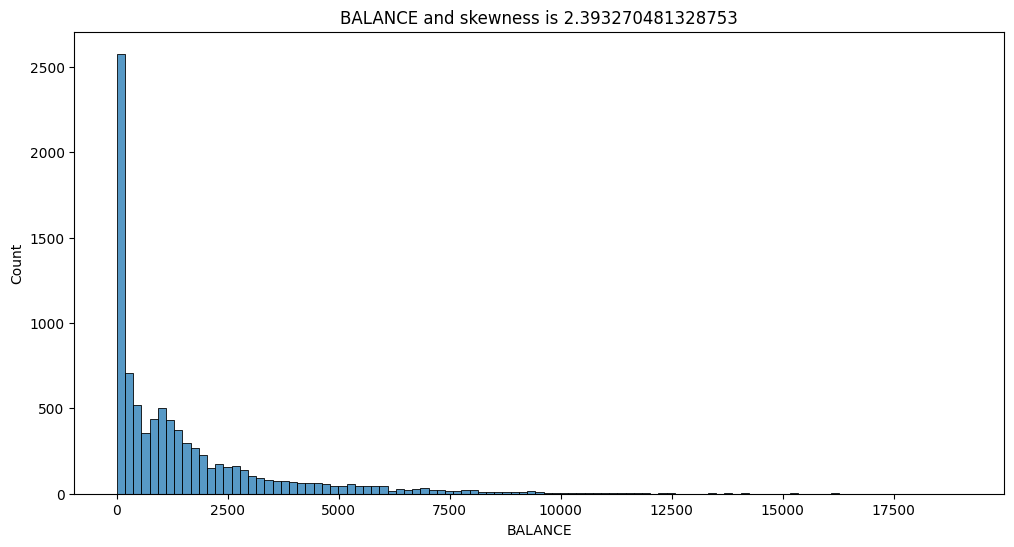

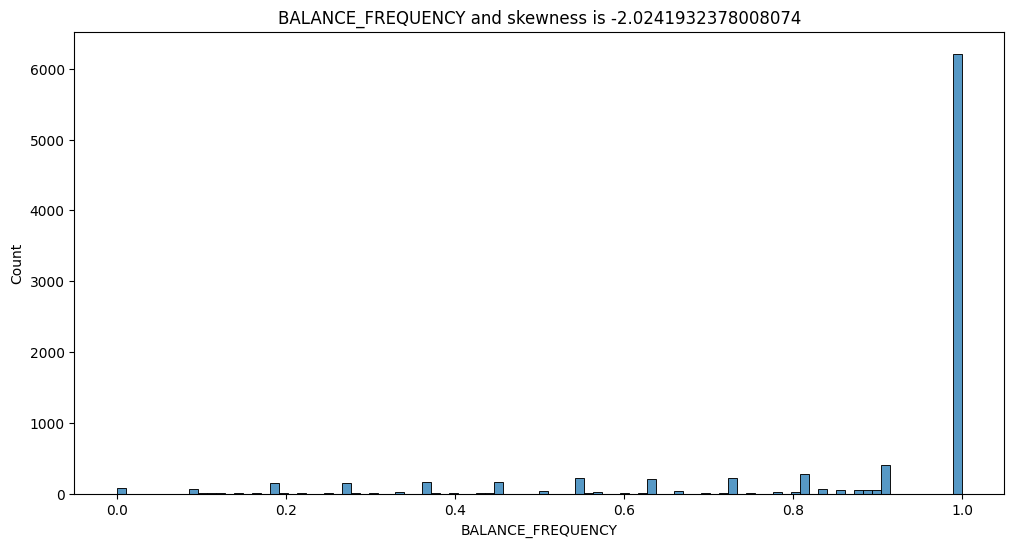

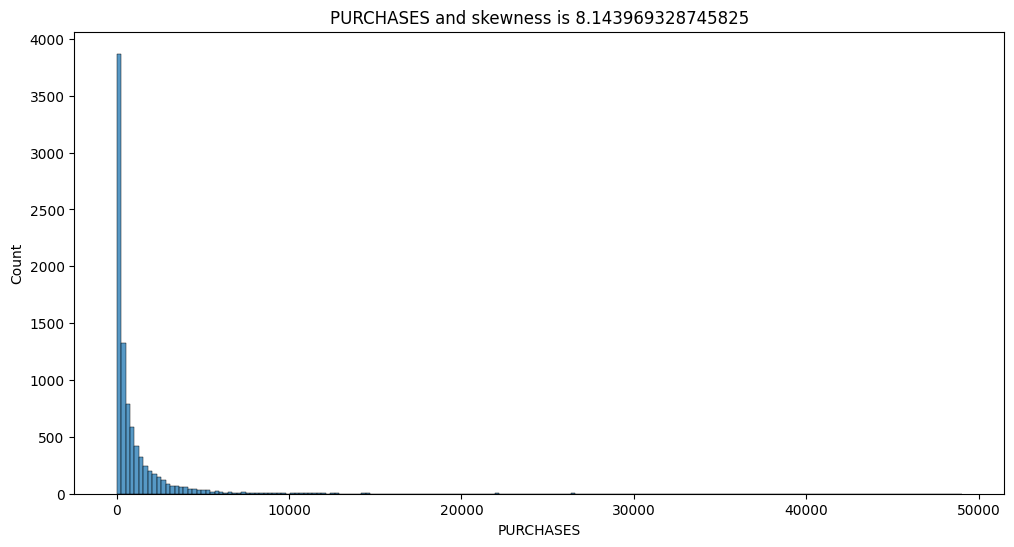

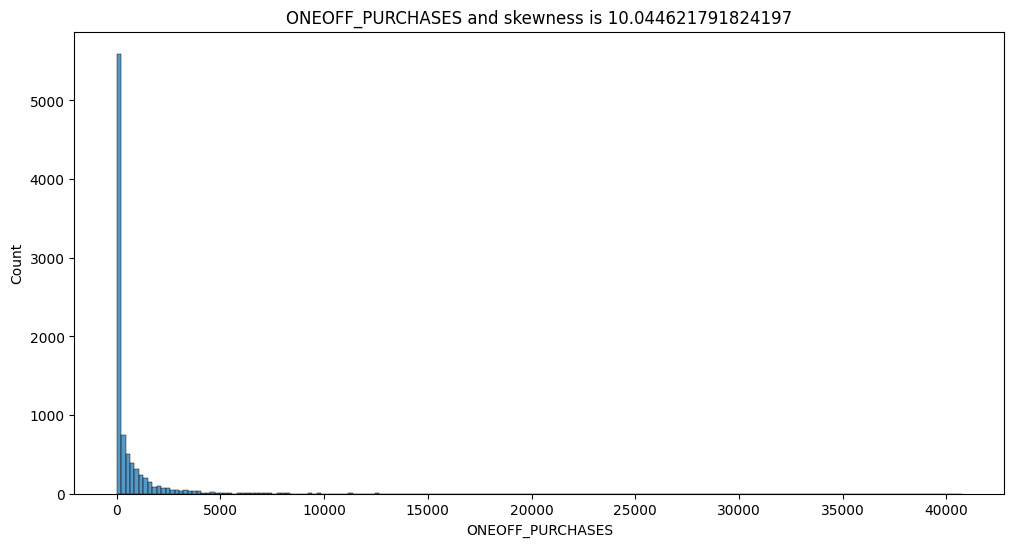

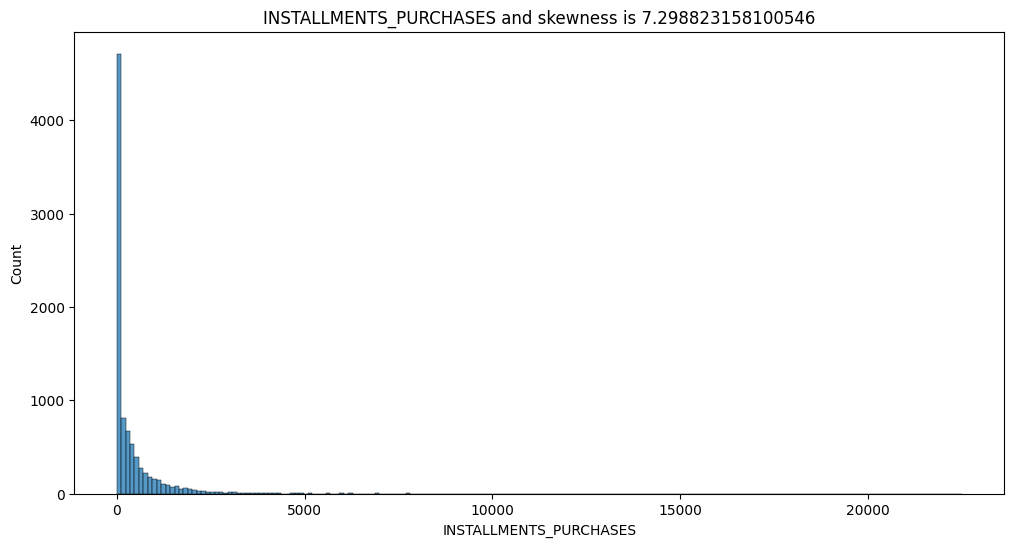

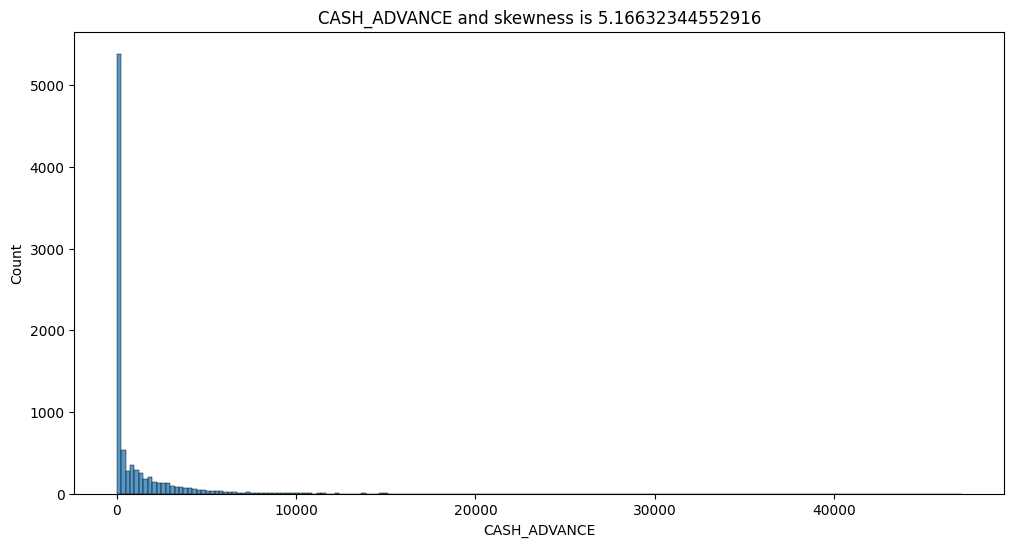

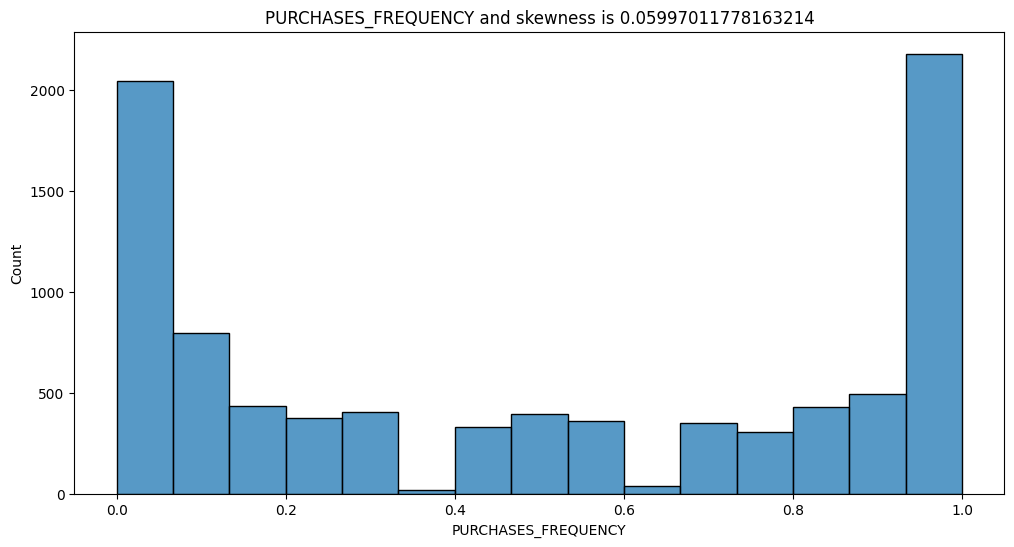

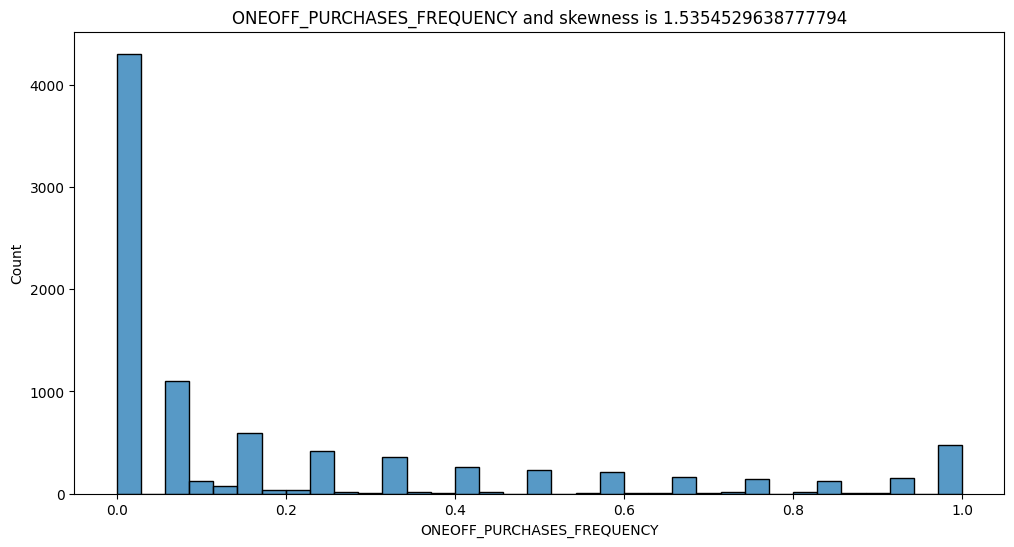

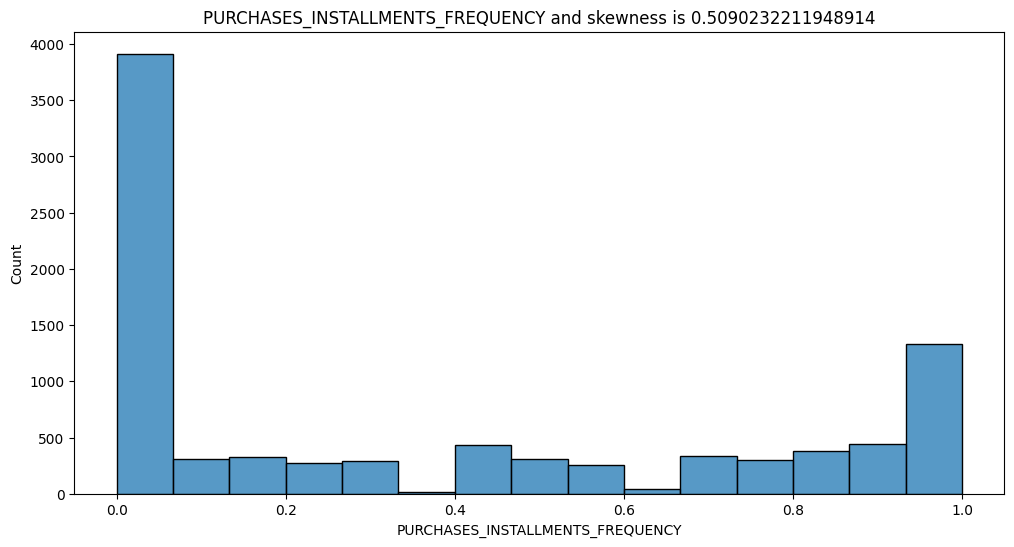

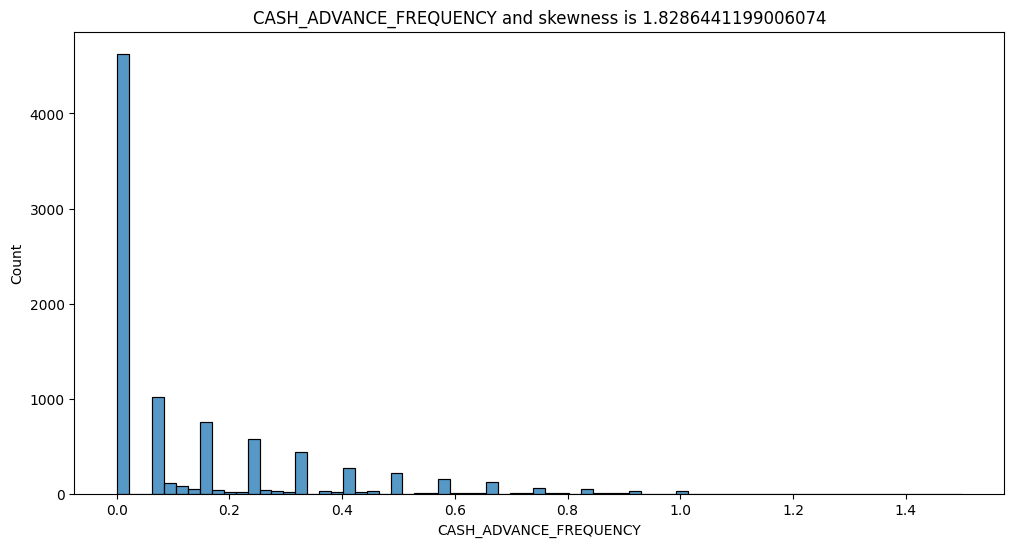

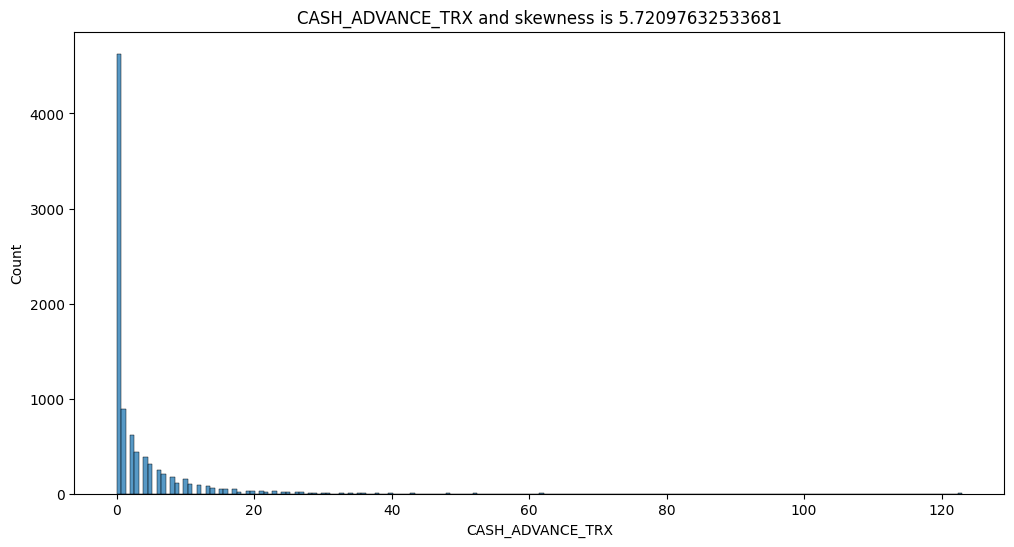

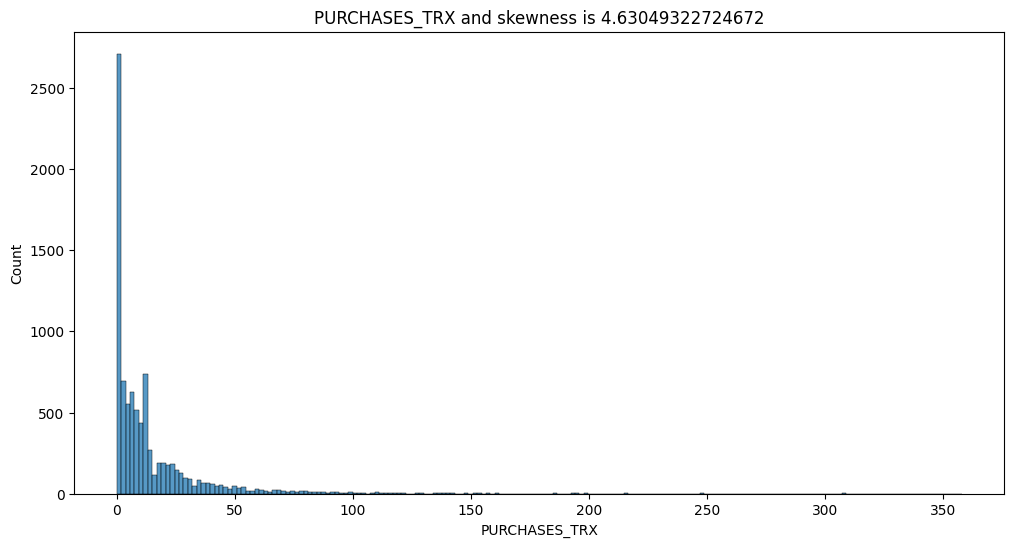

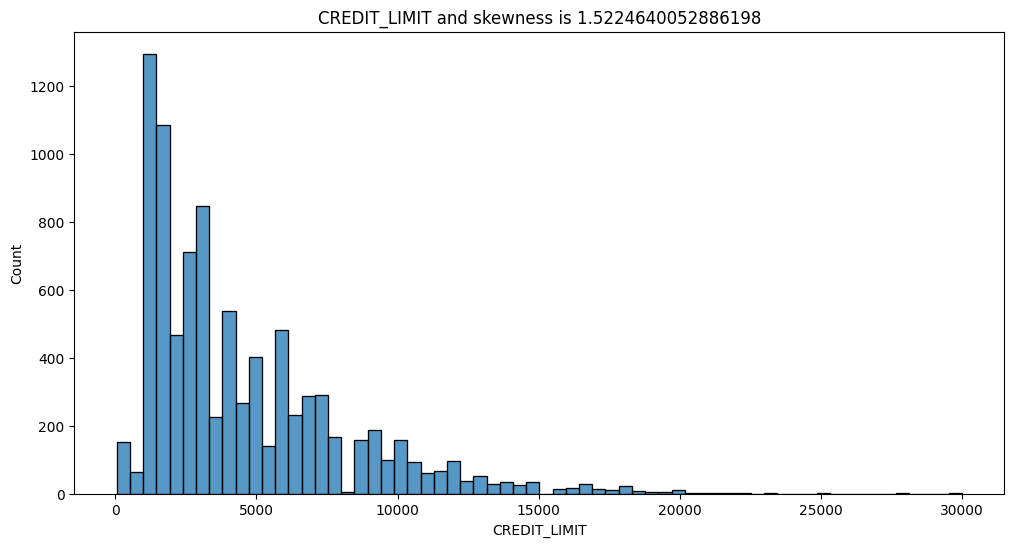

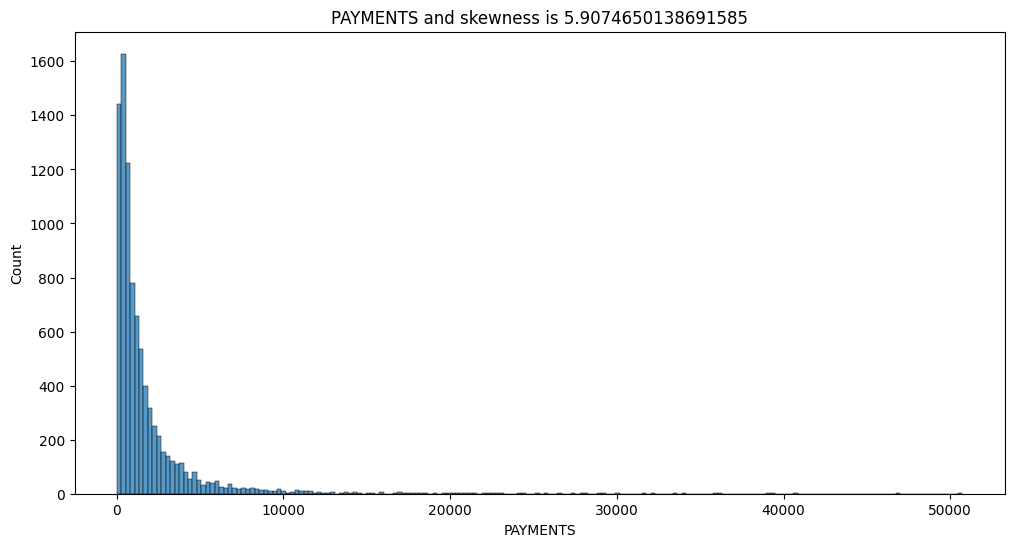

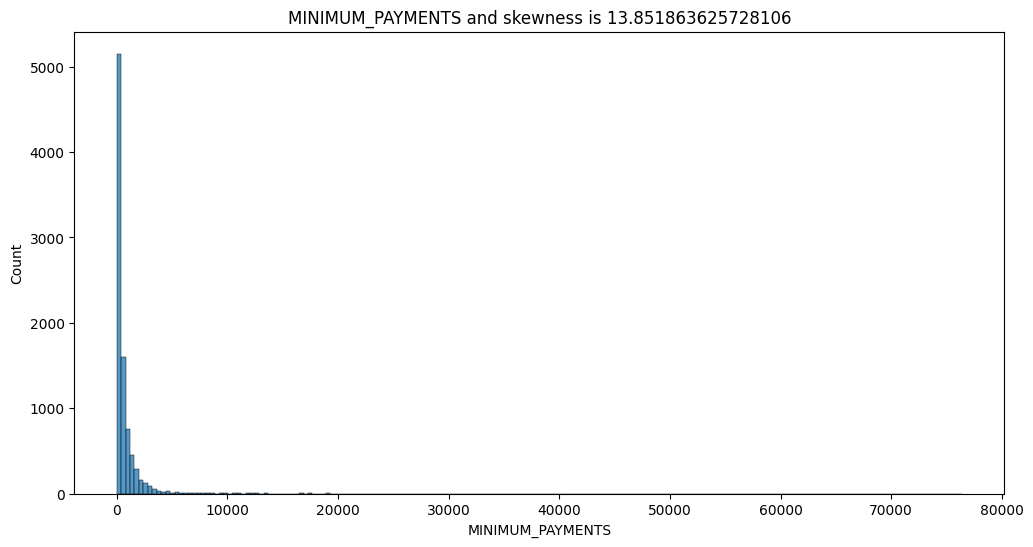

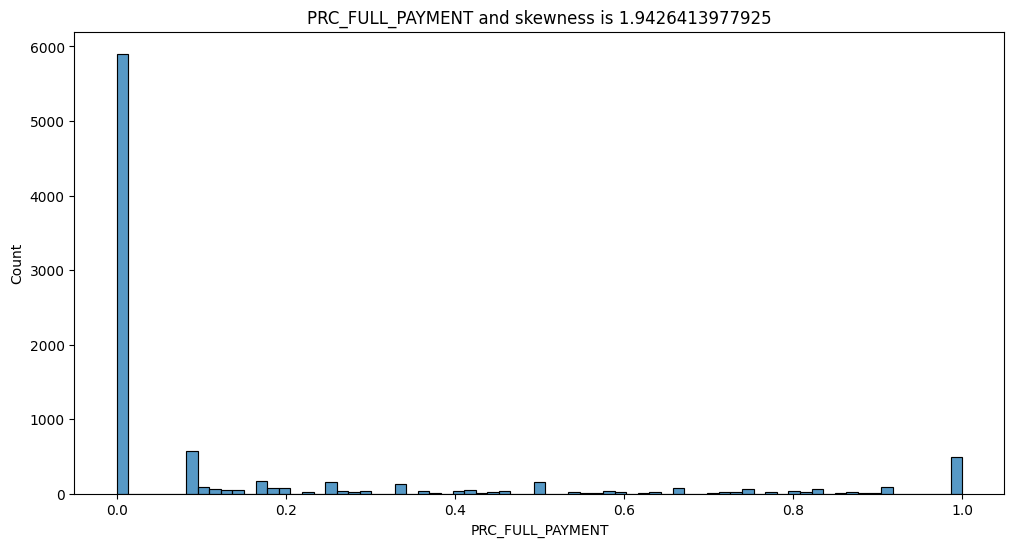

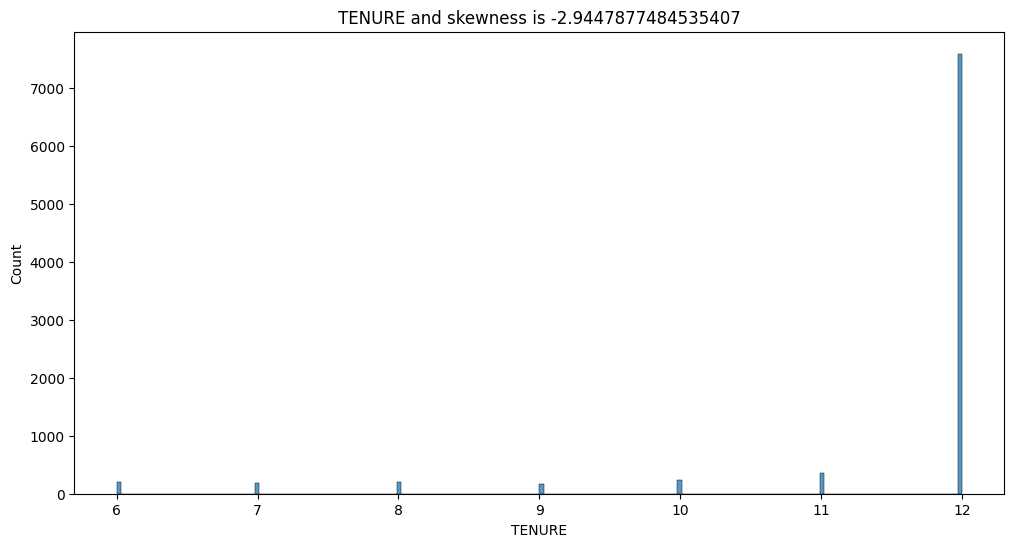

In [41]:
histogram(df1)

## Right skewed columns
####         ONEOFF_PURCHASES    ,   PURCHASES     ,BALANCE     ,     CASH_ADVANCE       
####   CASH_ADVANCE_FREQUENCY ,  ONEOFF_PURCHASES_FREQUENCY  ,      INSTALLMENTS_PURCHASES            
####  PRC_FULL_PAYMENT ,MINIMUM_PAYMENTS,PAYMENTS ,CREDIT_LIMIT,PURCHASES_TRX, CASH_ADVANCE_TRX

## Left skew columns
#### TENURE and BALANCE_FREQUENCY   

## Normal   columns
####   PURCHASES_INSTALLMENTS_FREQUENCY and PURCHASES_FREQUENCY

## here pass all the columns expect normal

In [19]:
clip_col=[0,1,2,3,4,5,7,9,10,11,12,13,14,15,16]
df1=cliping(df1,clip_col)

In [92]:
df1.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1.0,1.0,7500.0,0.000000,312.452292,0.000000,12.0
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0


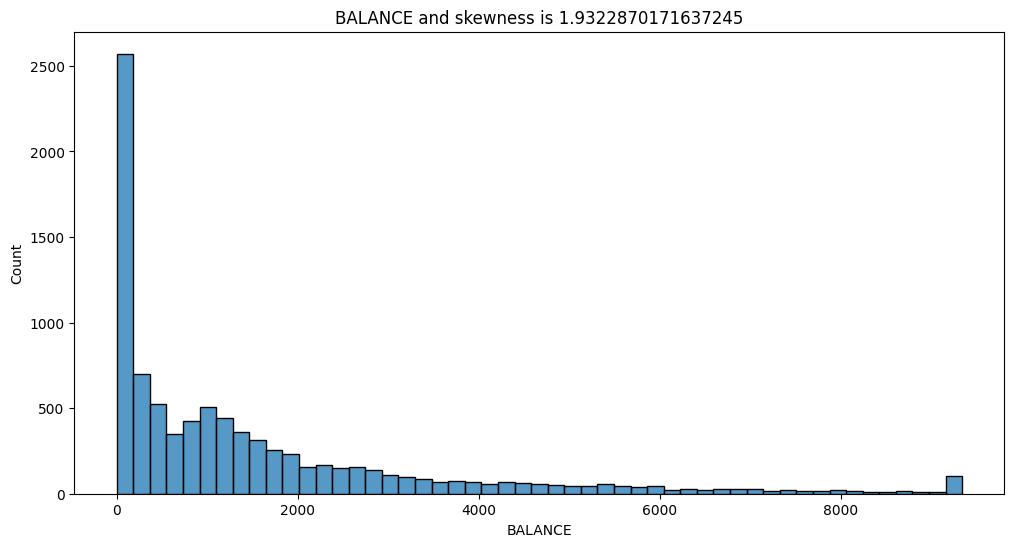

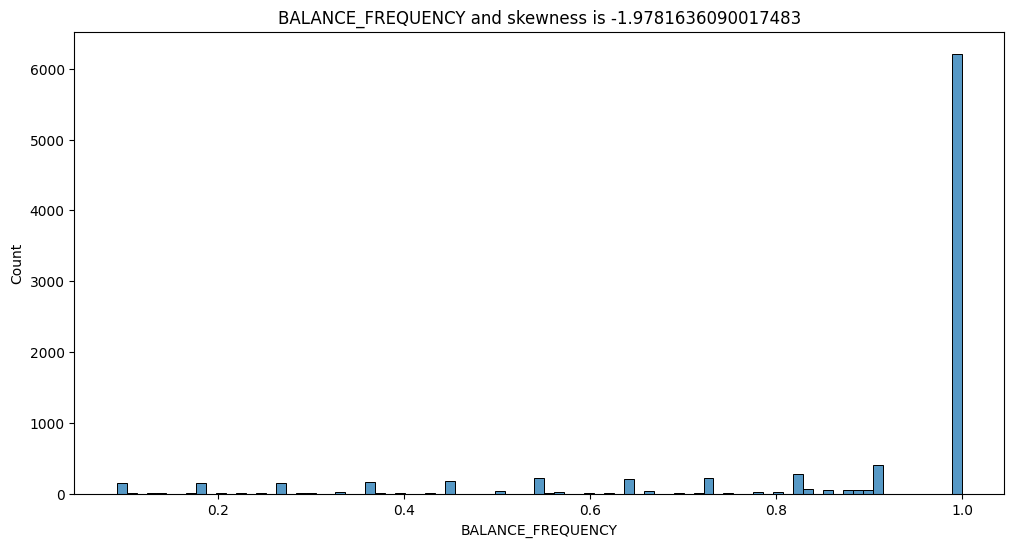

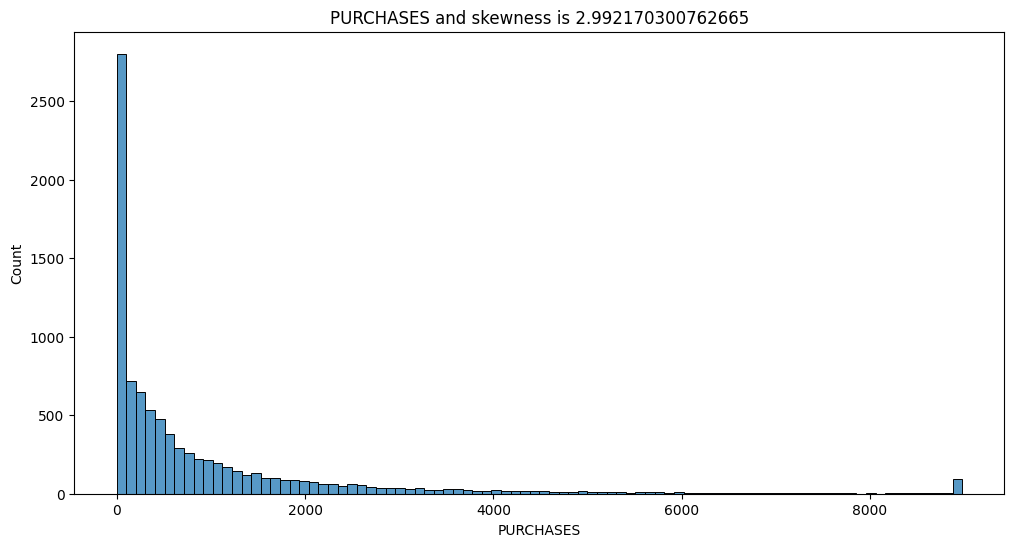

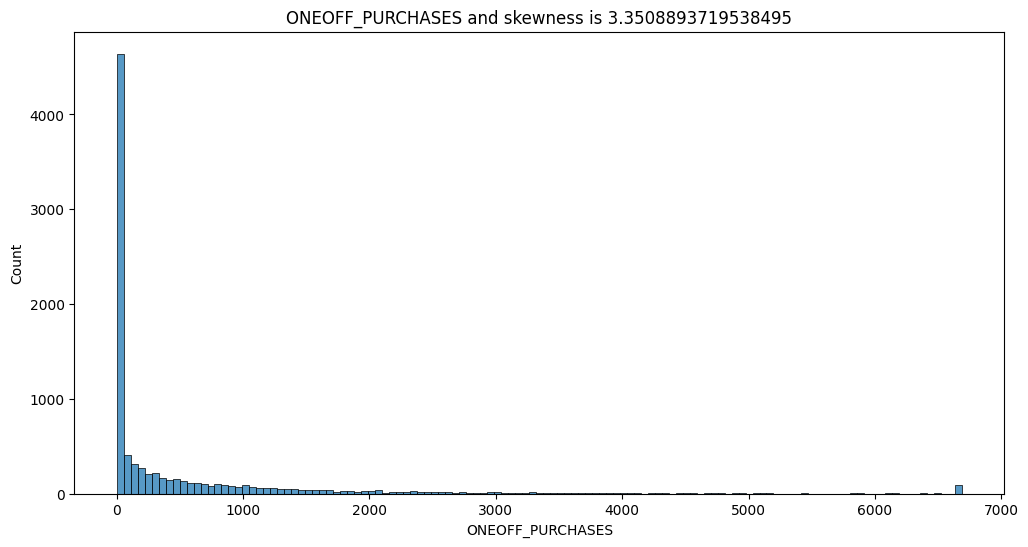

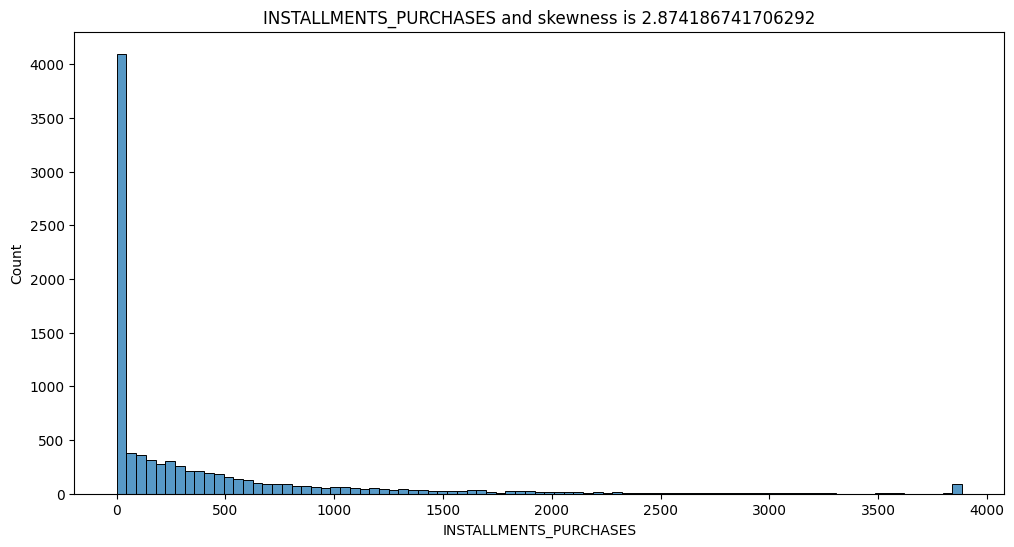

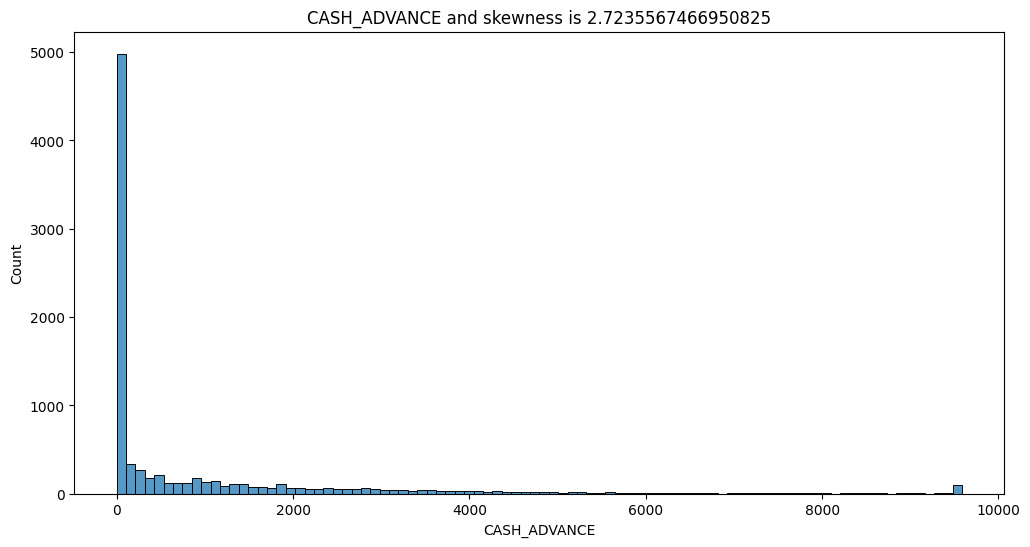

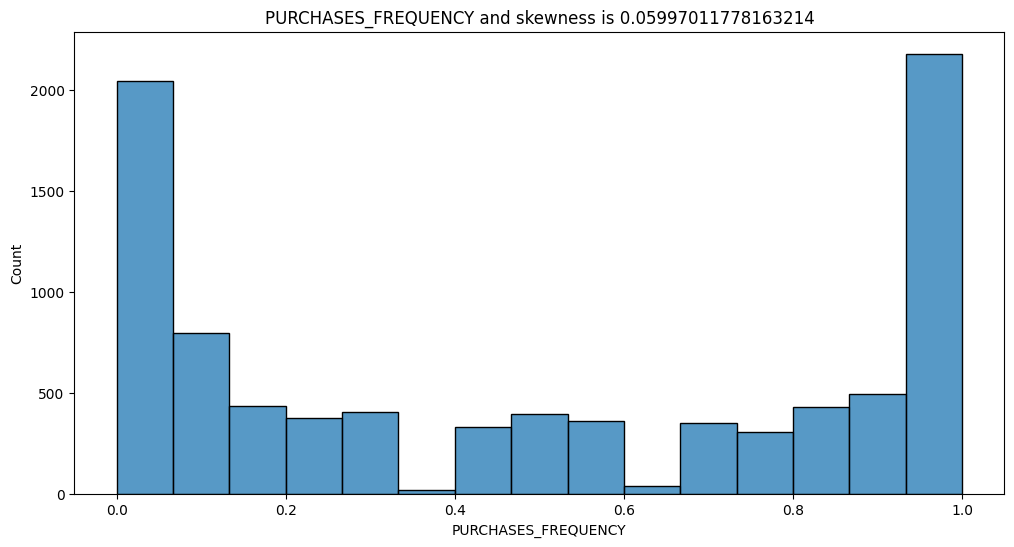

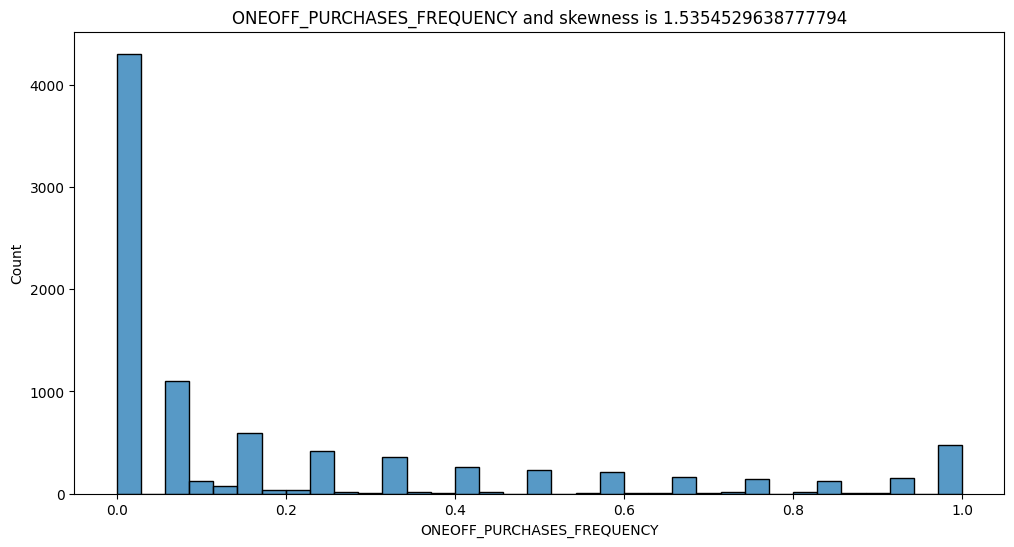

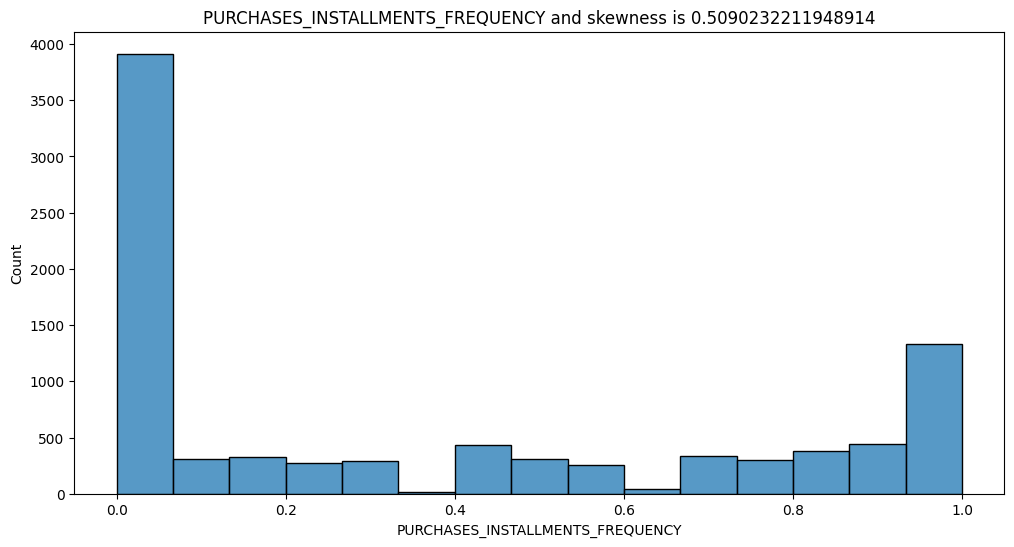

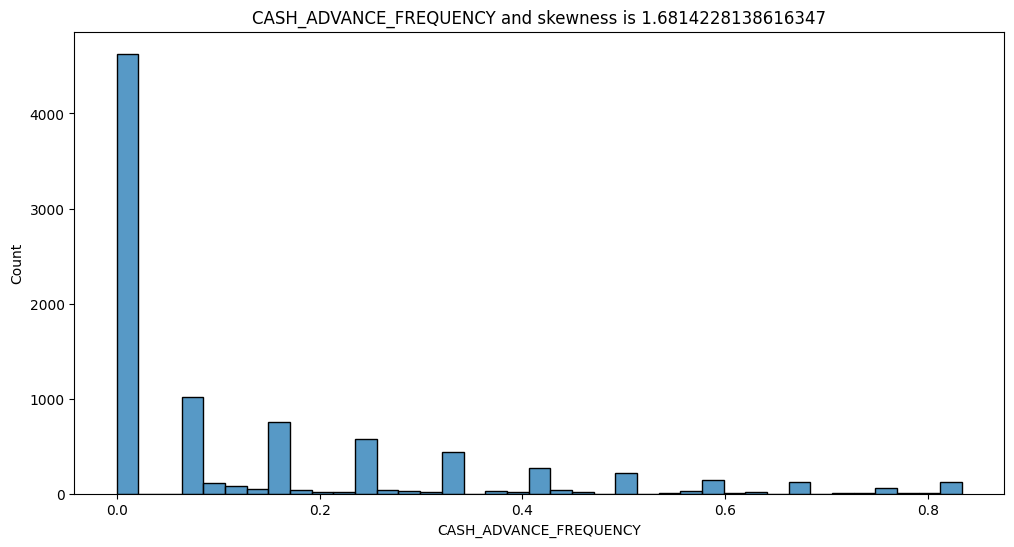

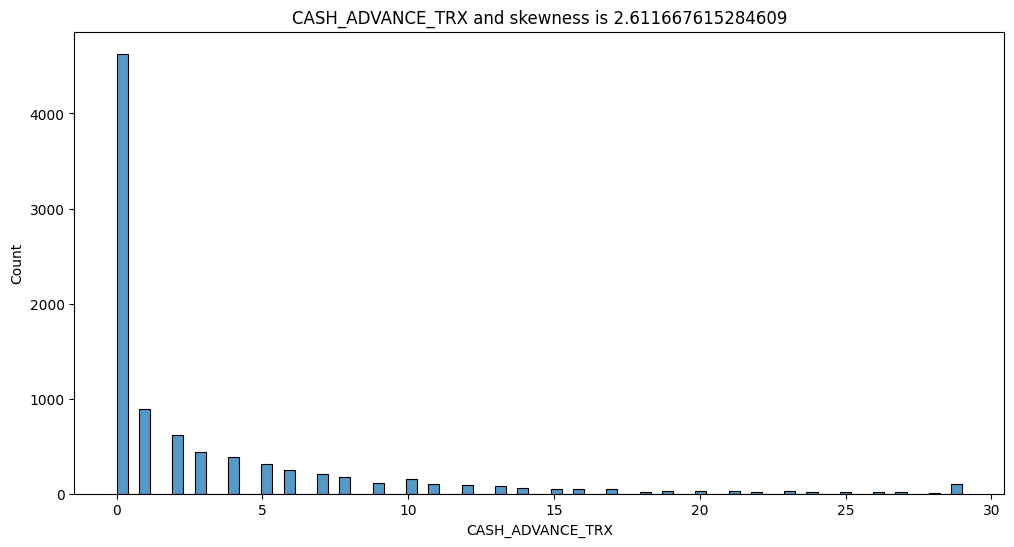

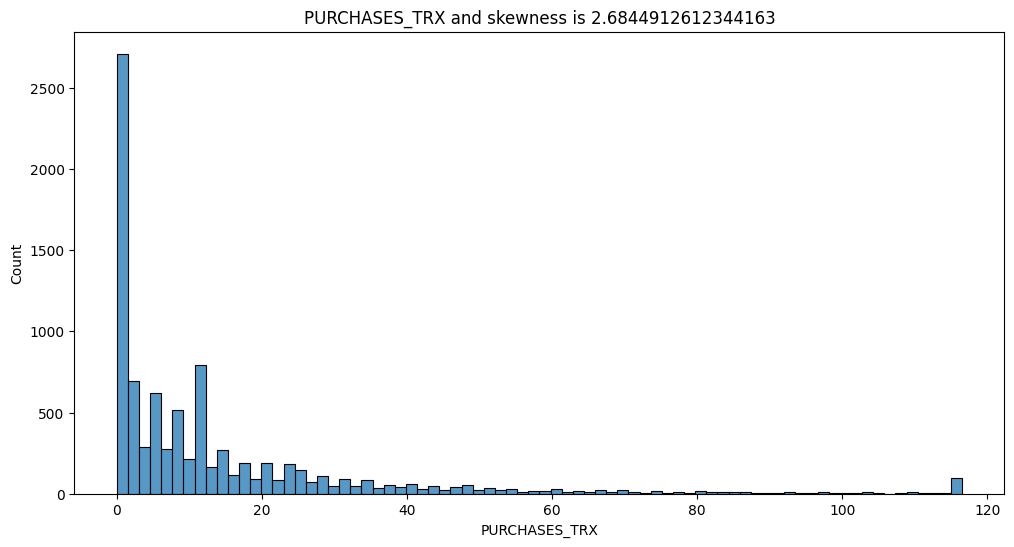

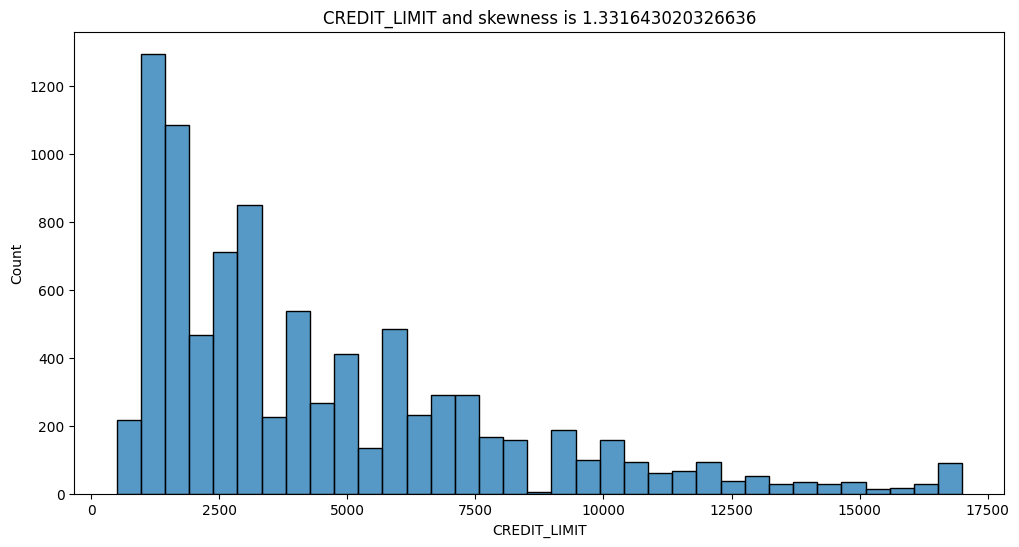

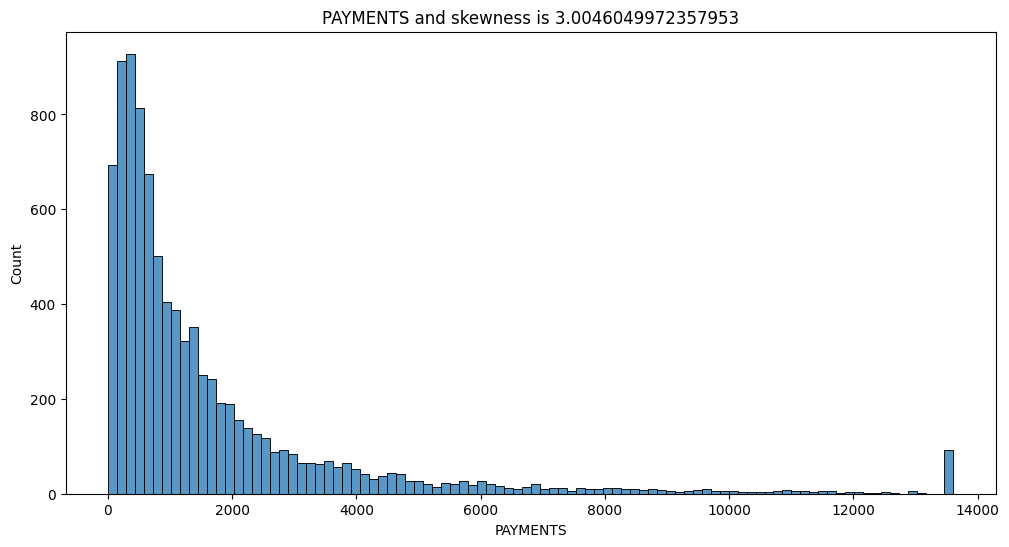

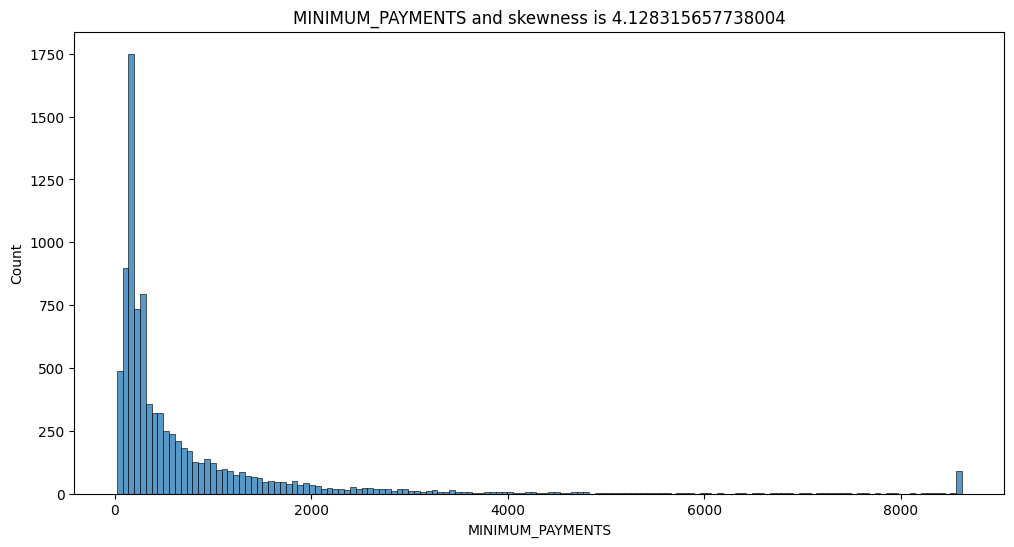

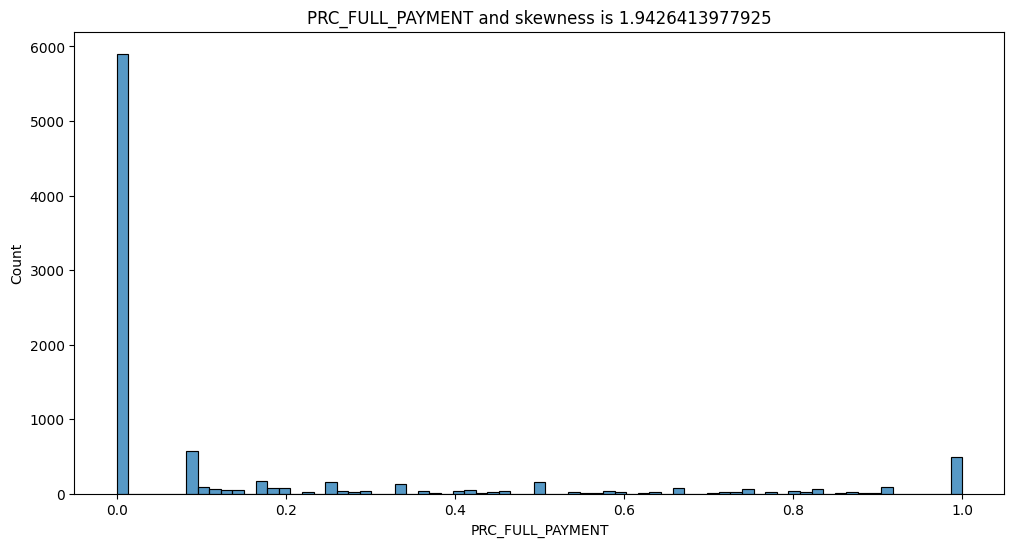

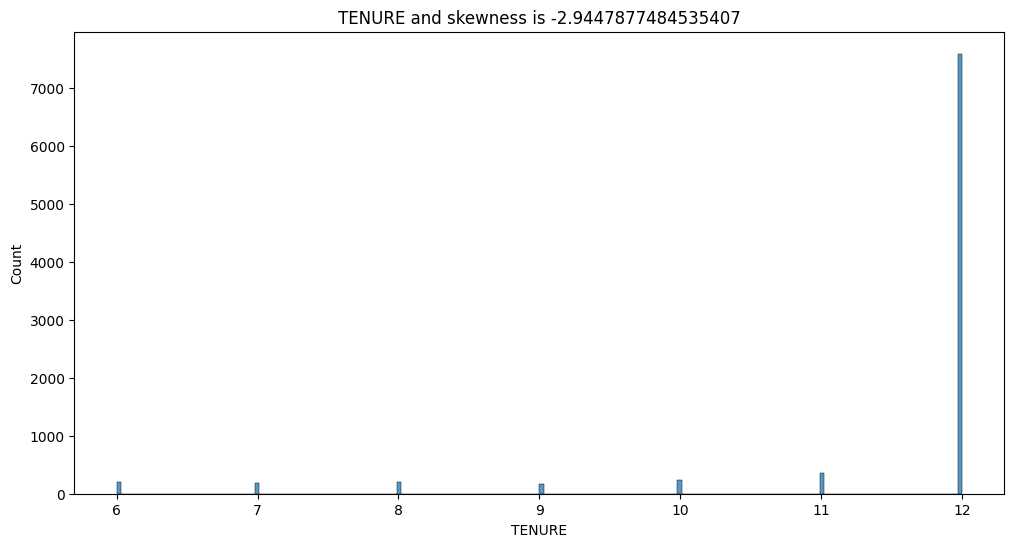

In [70]:
histogram(df1)
    

### pass the  left skewed column not all 
### some left skew columns transformation make right skew so avoid these 

In [20]:
log_list=[0,2,3,4,5,10,12,14]
df1=log(df1,log_list)

### pass the columns to sqrt funstion to normalize right skewness  because the log 
###  function transform it to left skew so .it was observe that sqrt is best choice

In [21]:
sqrt_list=[7,9,11,13,15]
df1=sqrt(df1,sqrt_list)

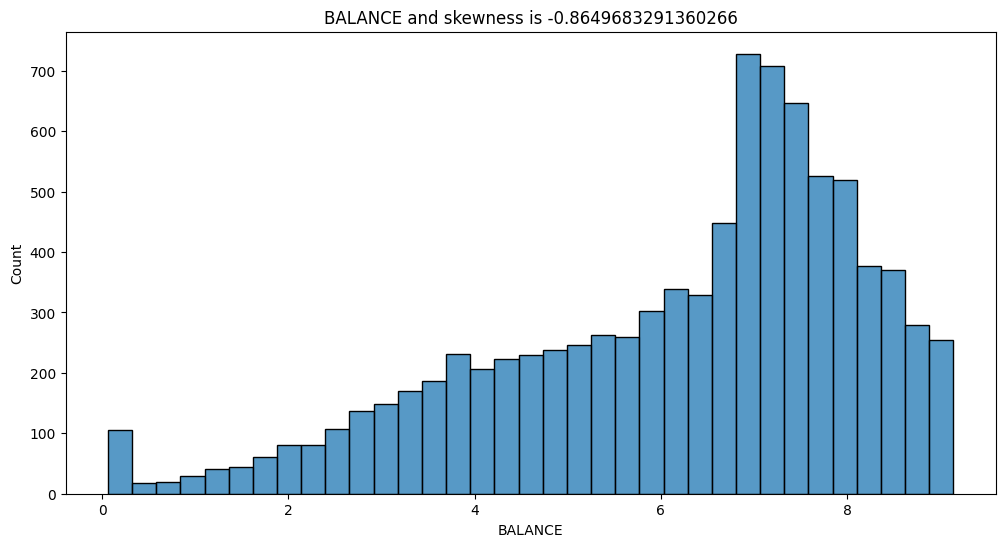

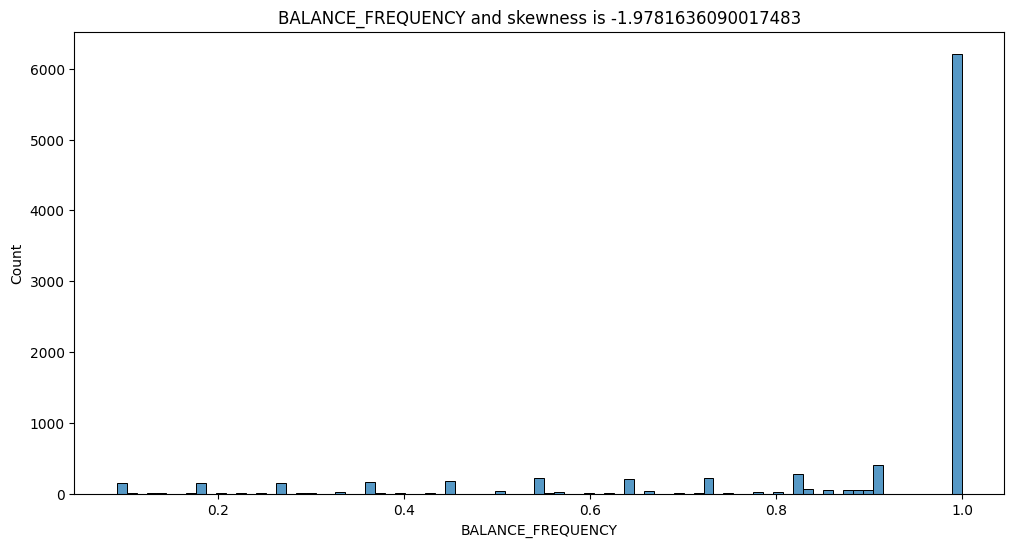

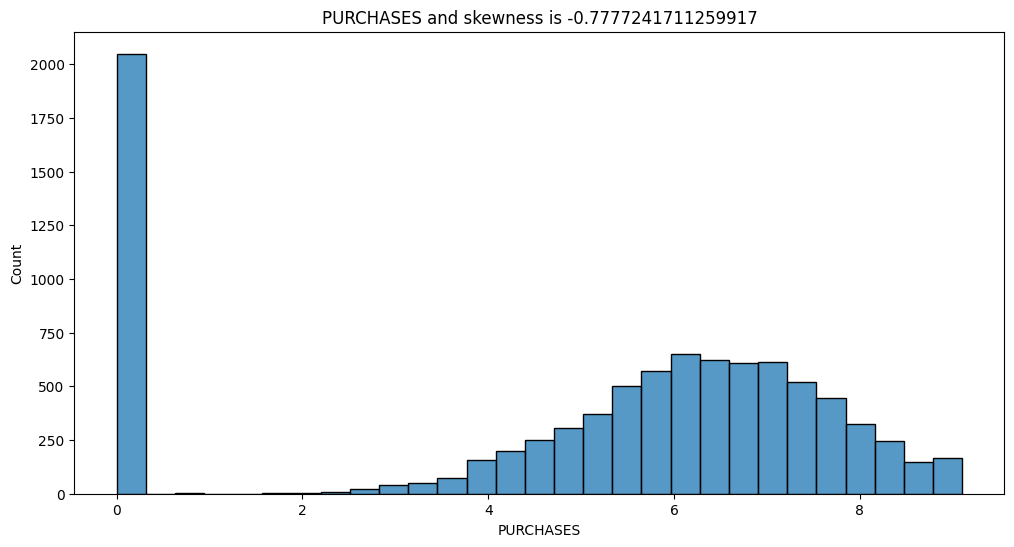

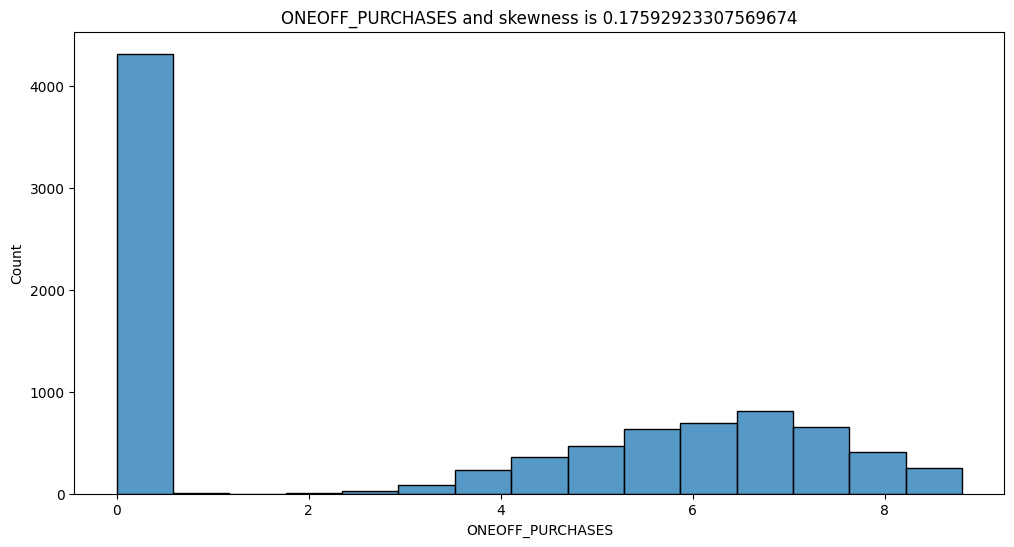

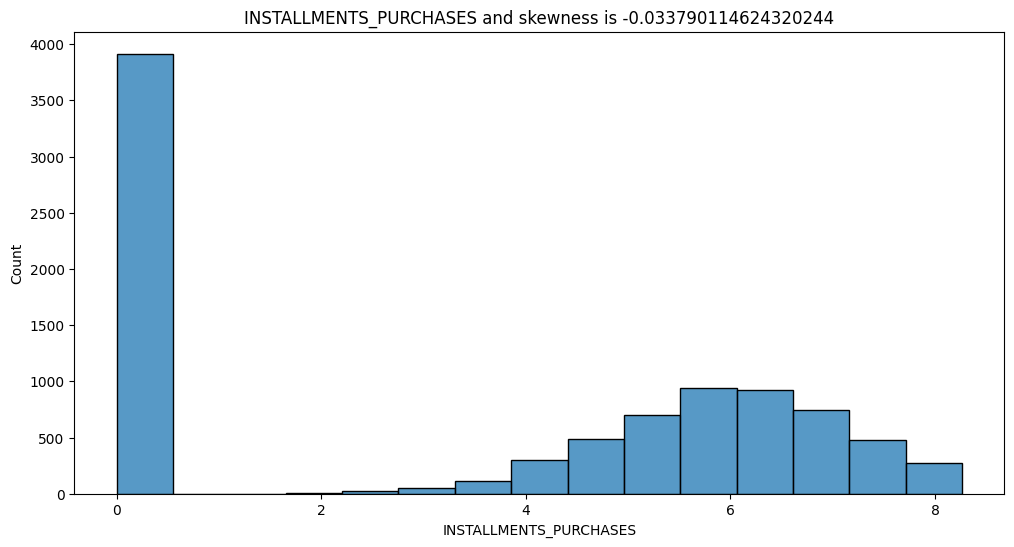

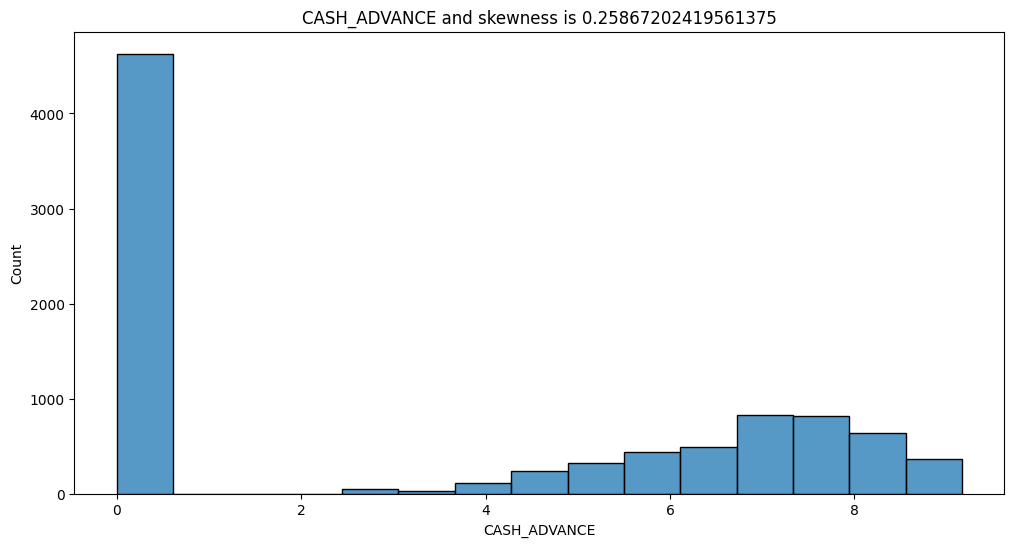

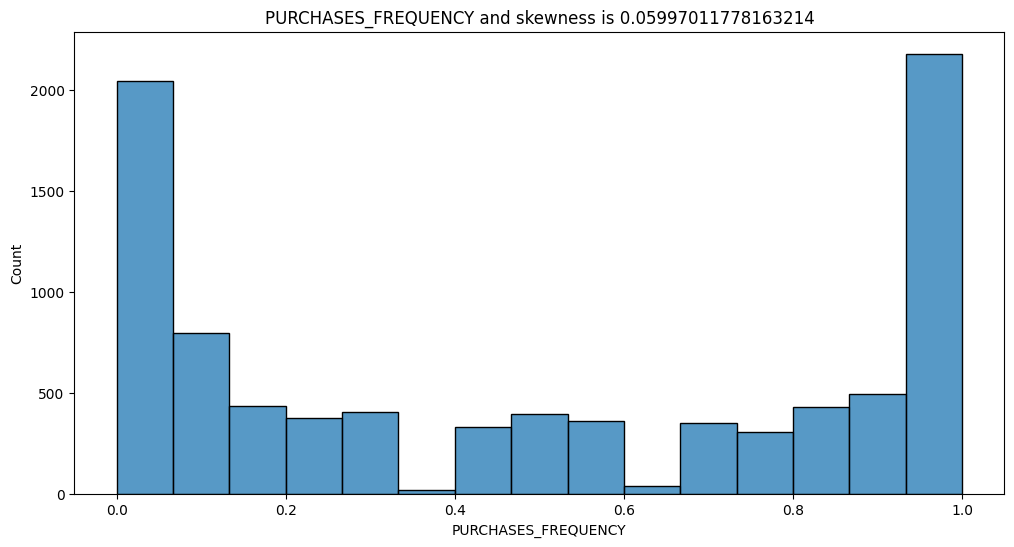

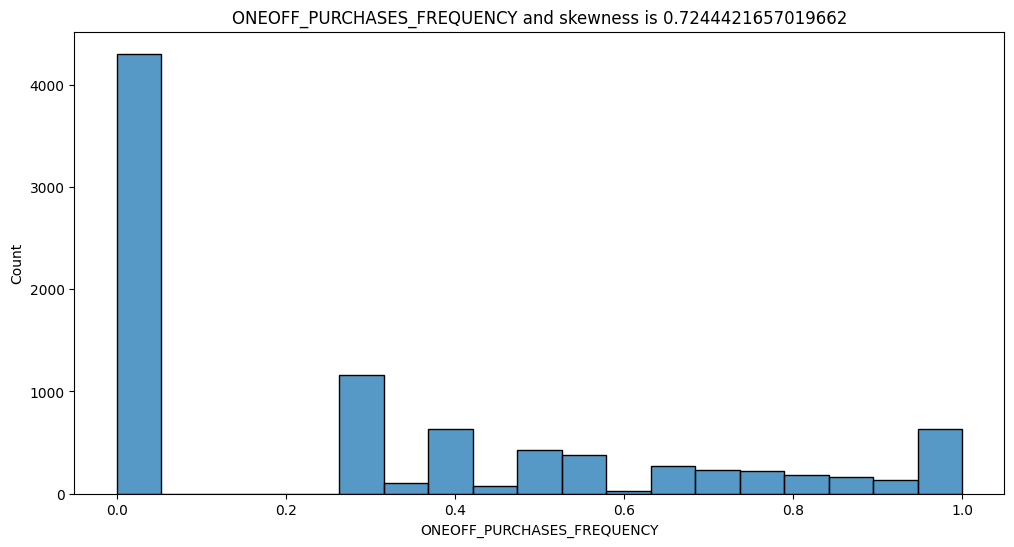

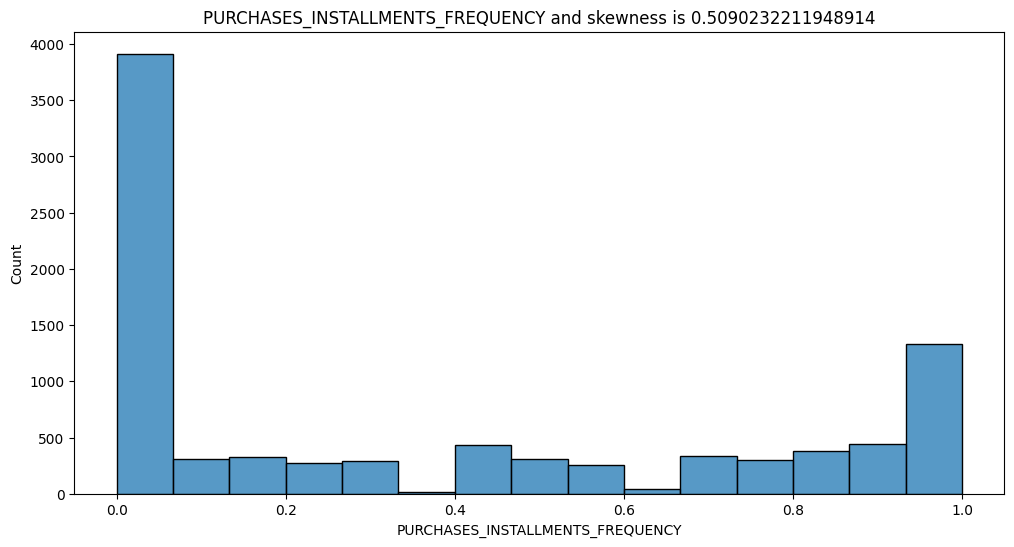

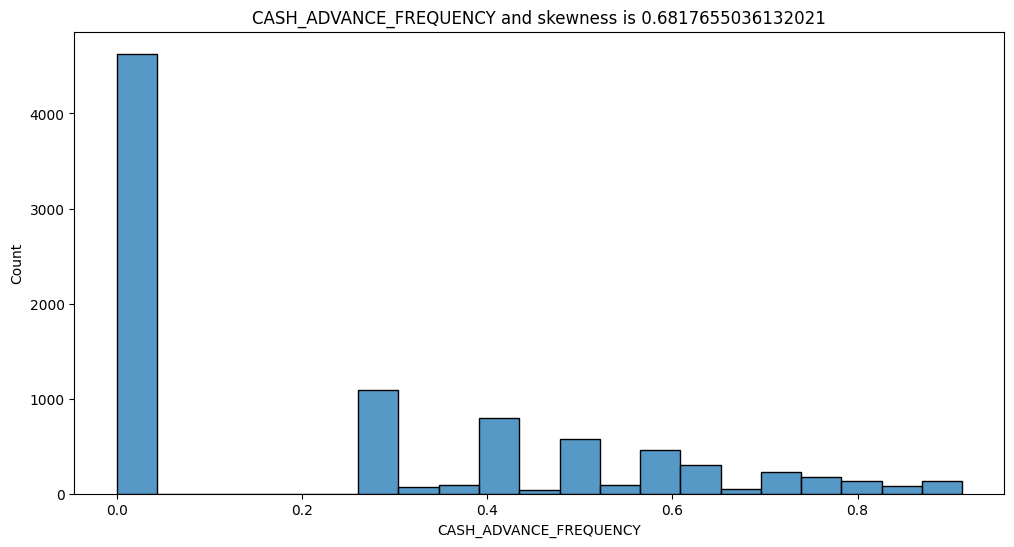

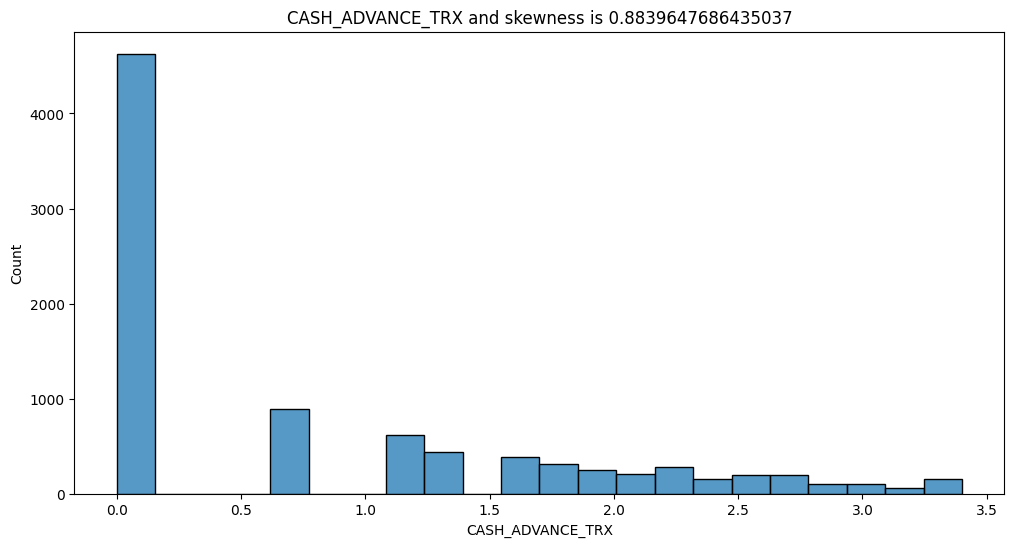

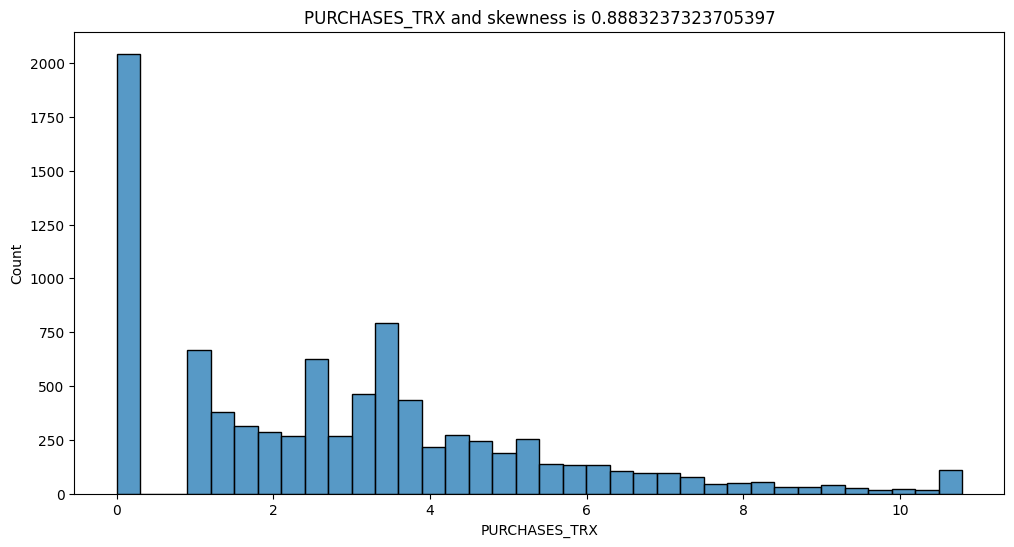

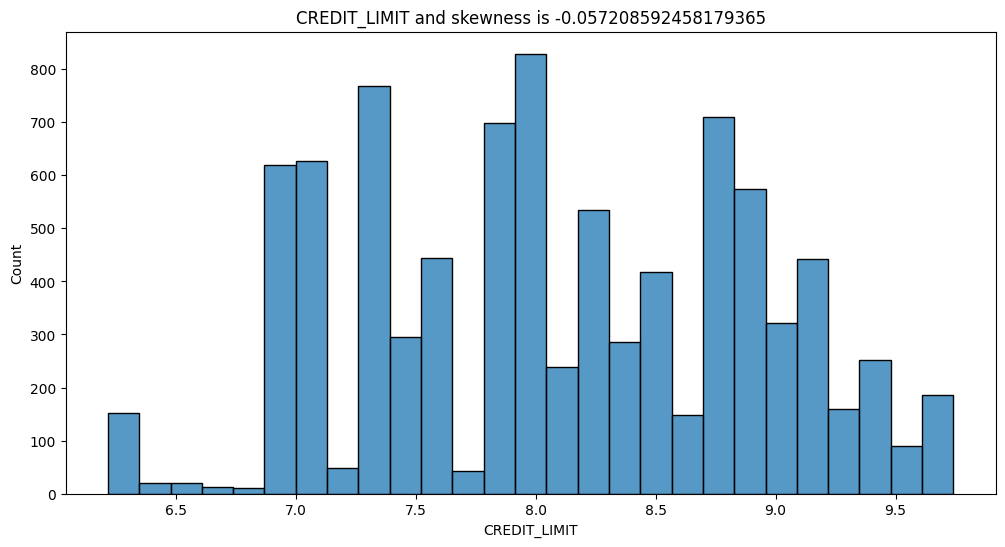

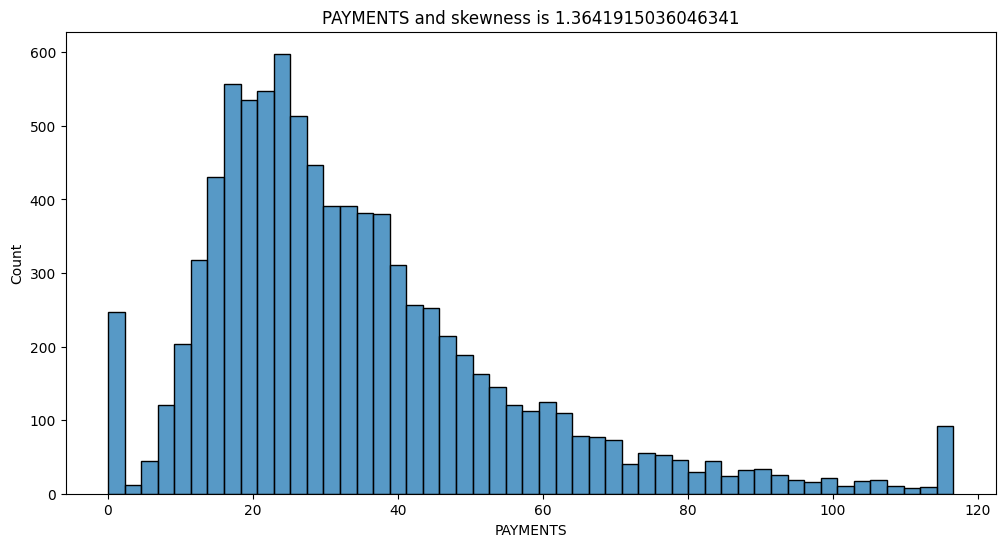

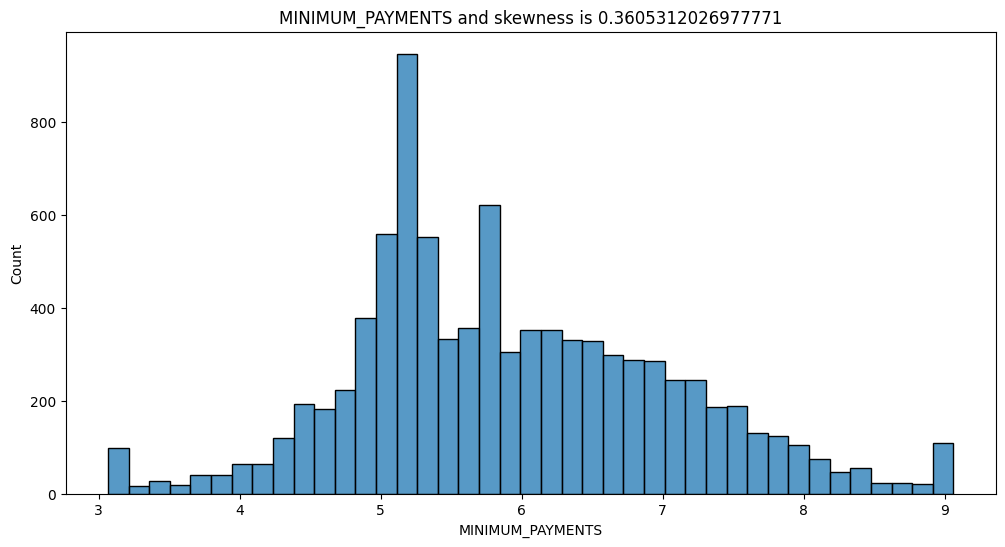

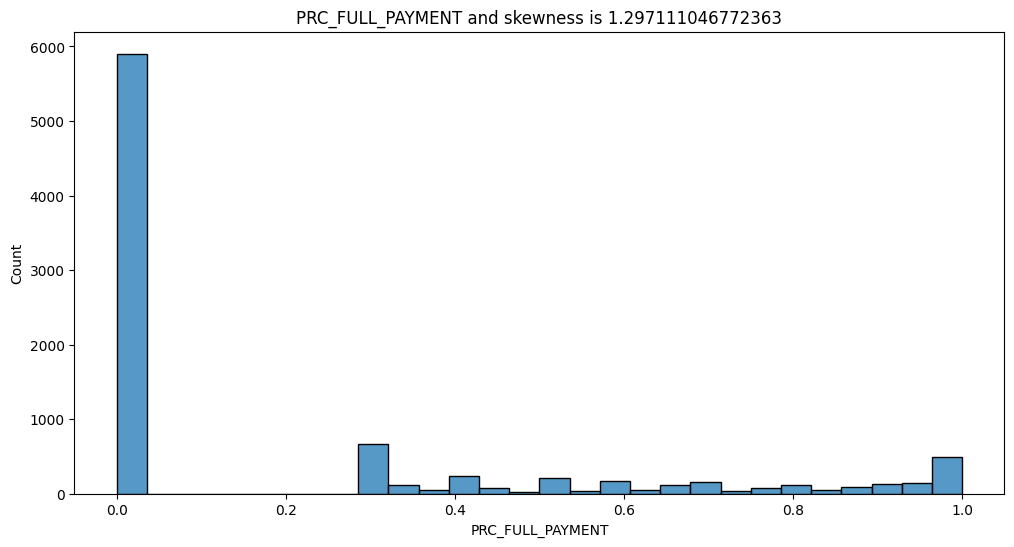

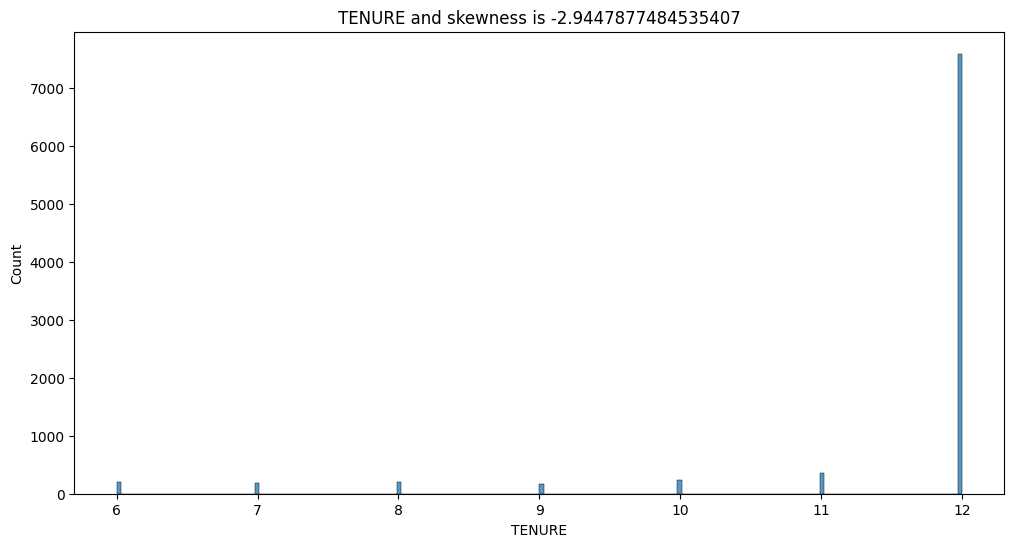

In [104]:
histogram(df1)

In [120]:
from sklearn.preprocessing import PowerTransformer

## now the step is for left skew 


### for BALANCE_FREQUENCY column first convert to right skew  and the apply log to normalize

In [134]:

x=df1['BALANCE_FREQUENCY'].max()+1-df1['BALANCE_FREQUENCY']
df1['BALANCE_FREQUENCY']=np.log1p(x)

### for TENURE column yeo-johnson method is used ,it tries different power transformation until
### skew ~=0

In [121]:
yeo=PowerTransformer(method='yeo-johnson',standardize=True)

In [135]:
df1['TENURE']=yeo.fit_transform(df1[['TENURE']])

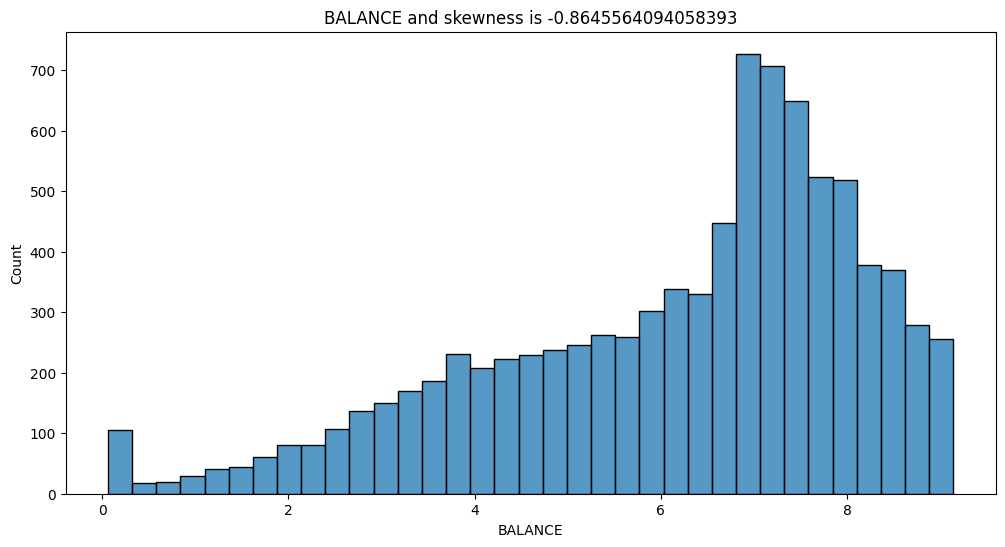

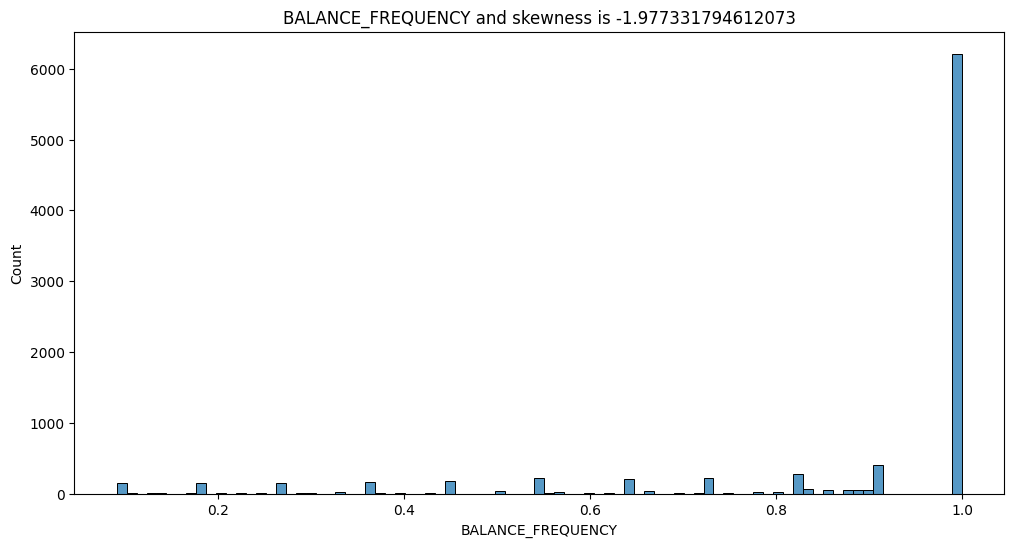

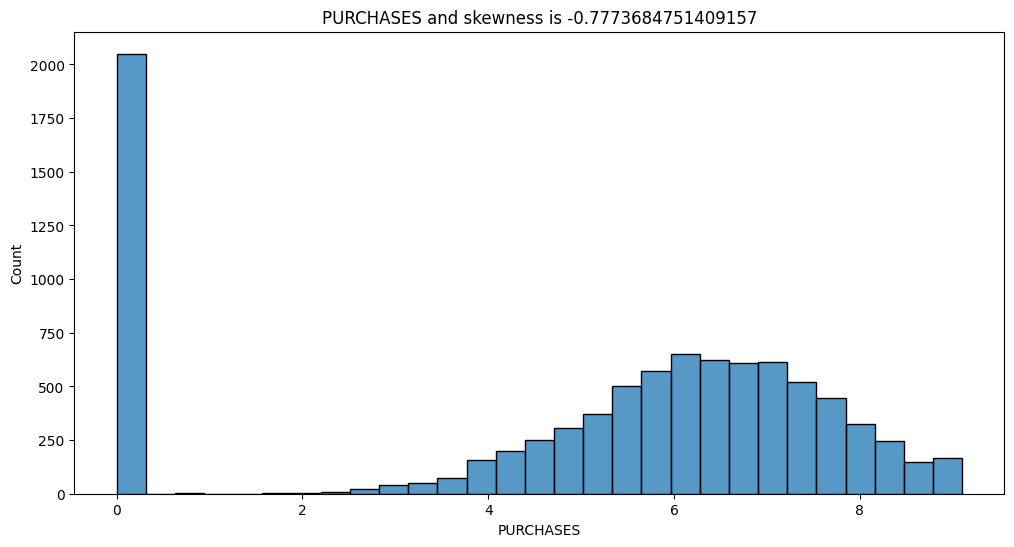

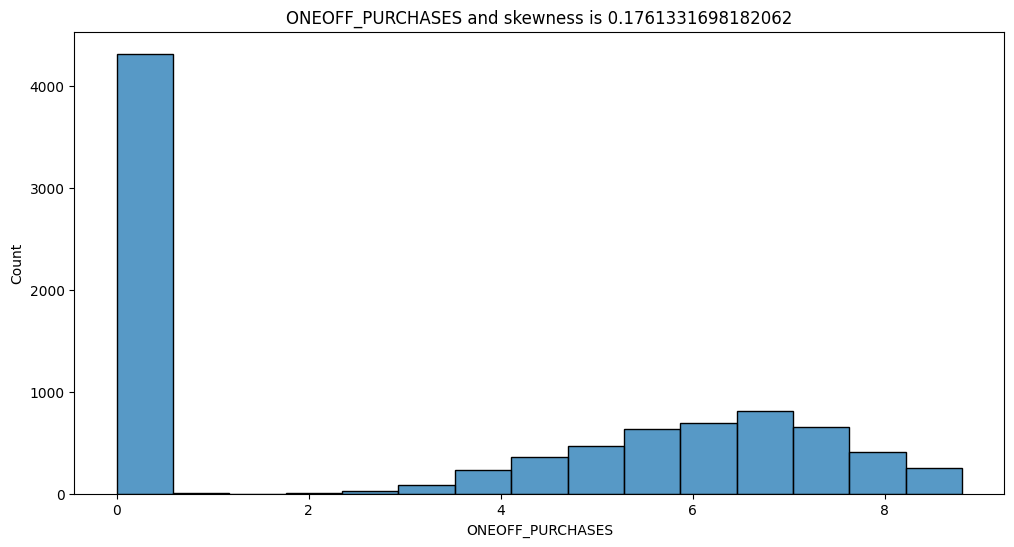

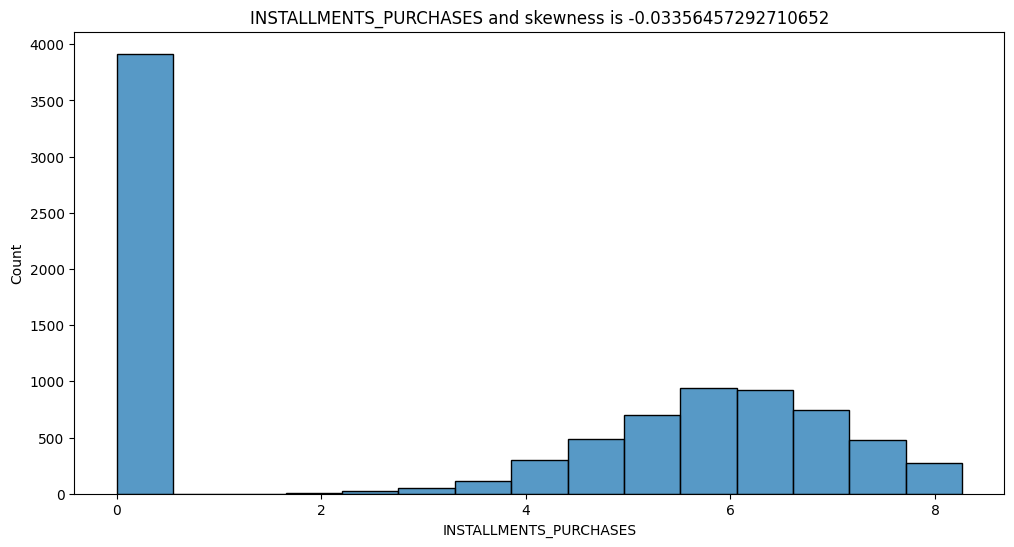

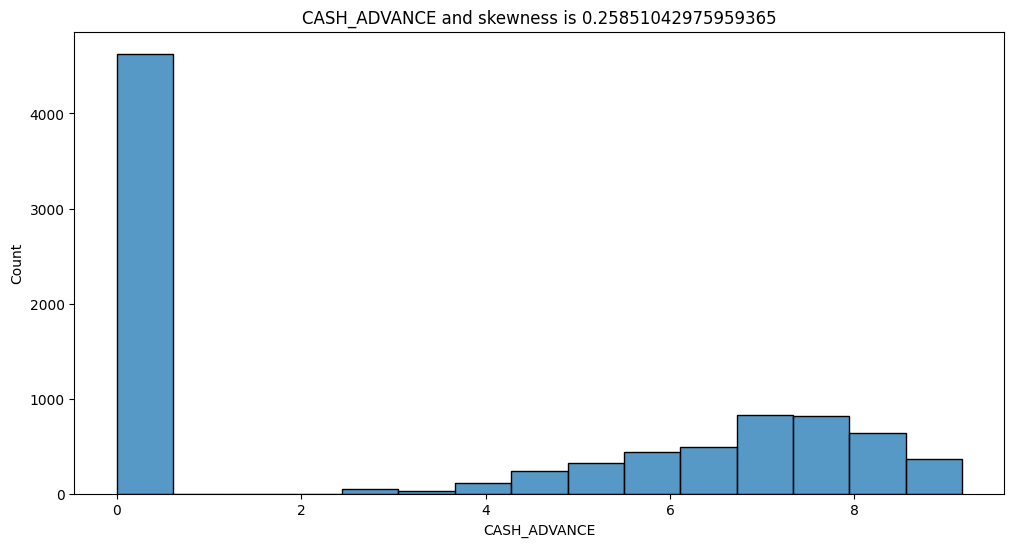

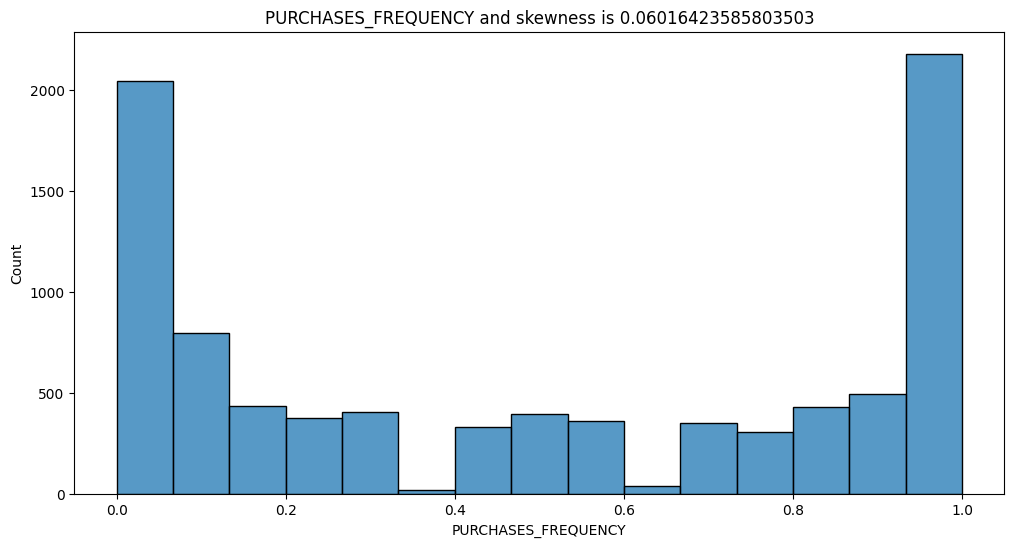

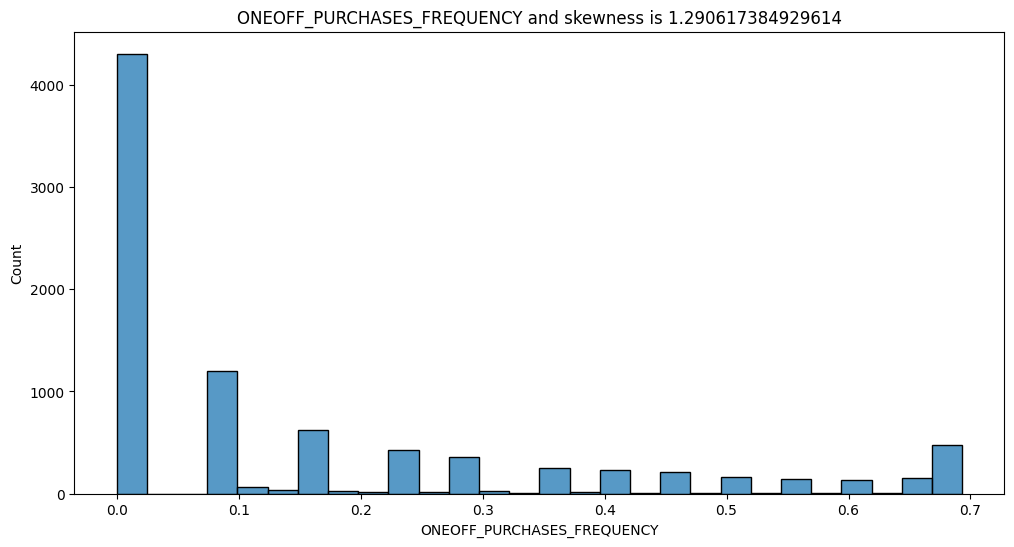

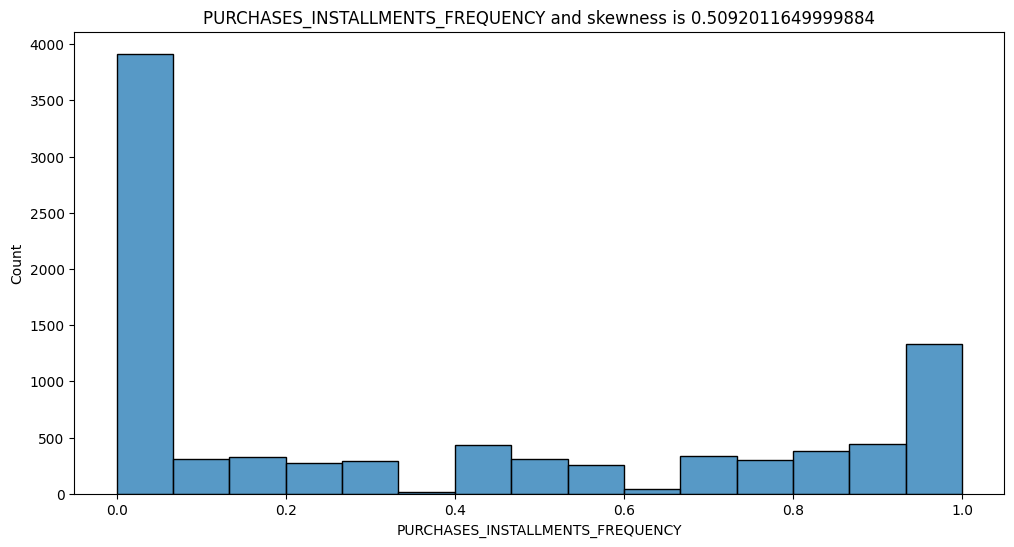

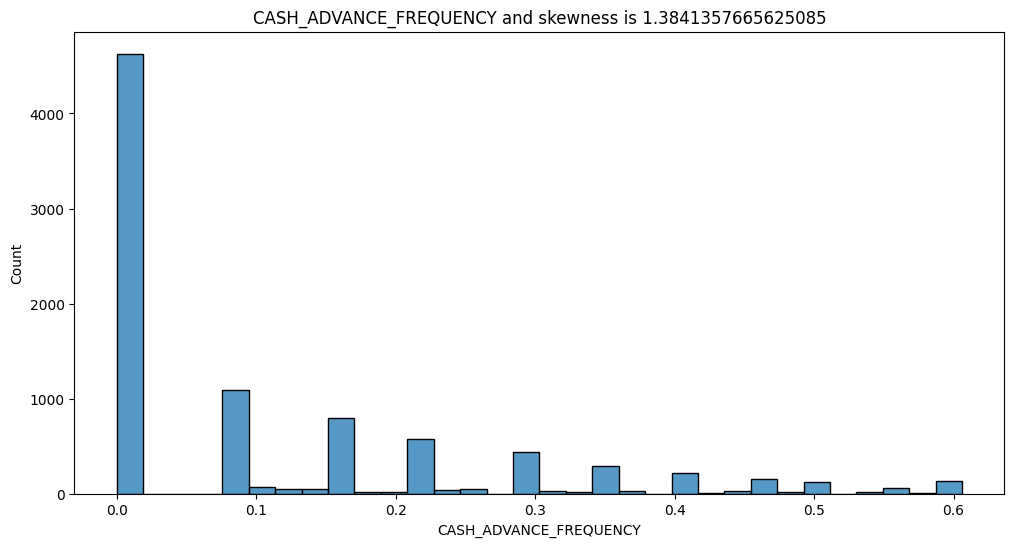

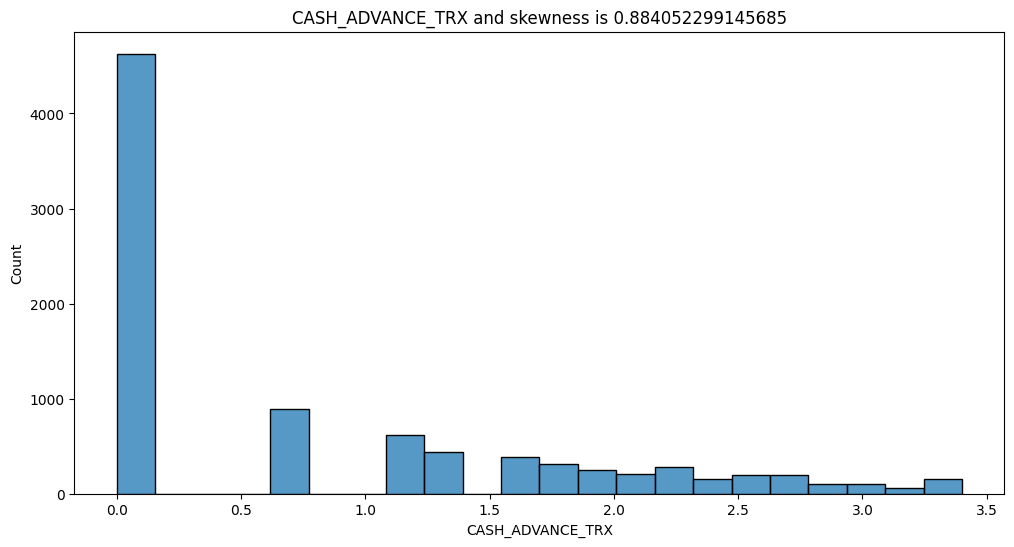

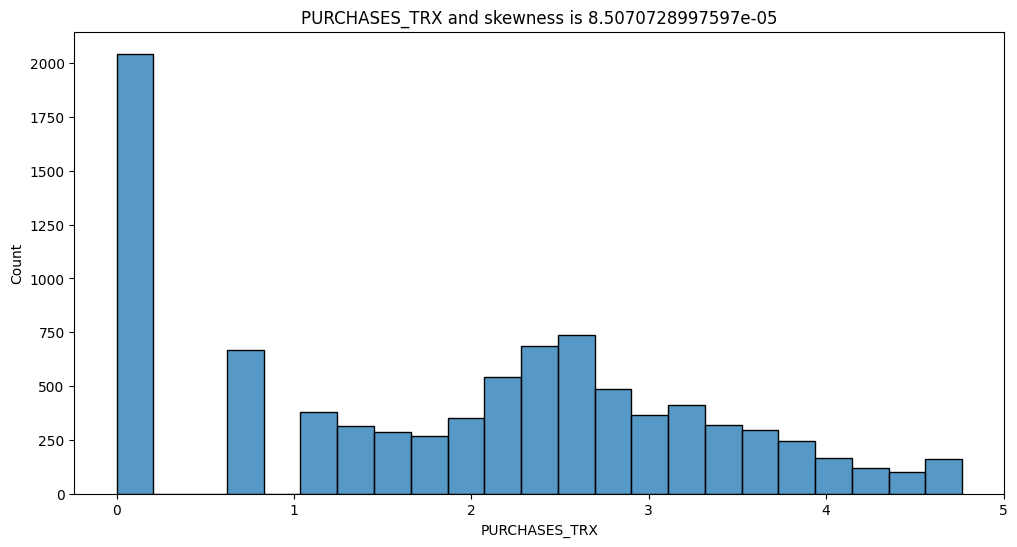

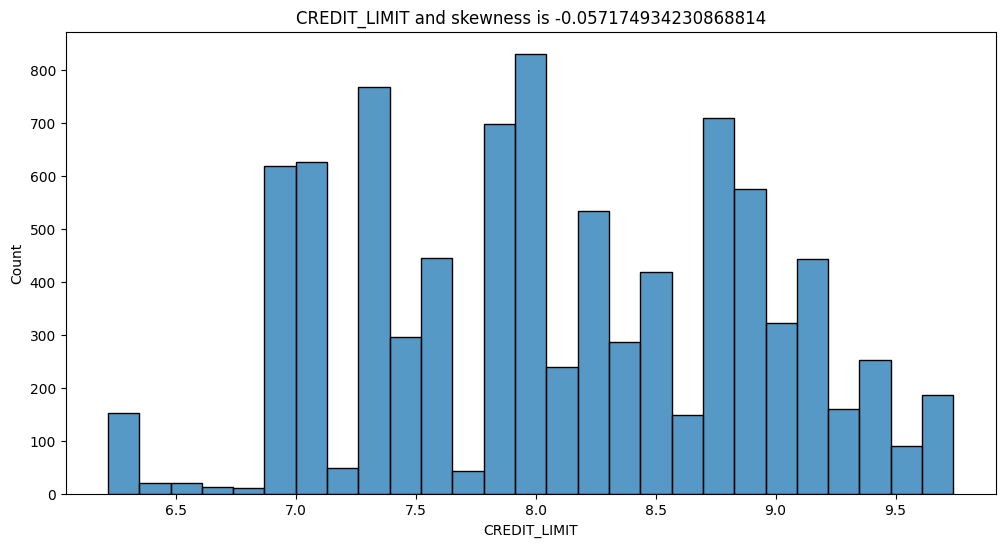

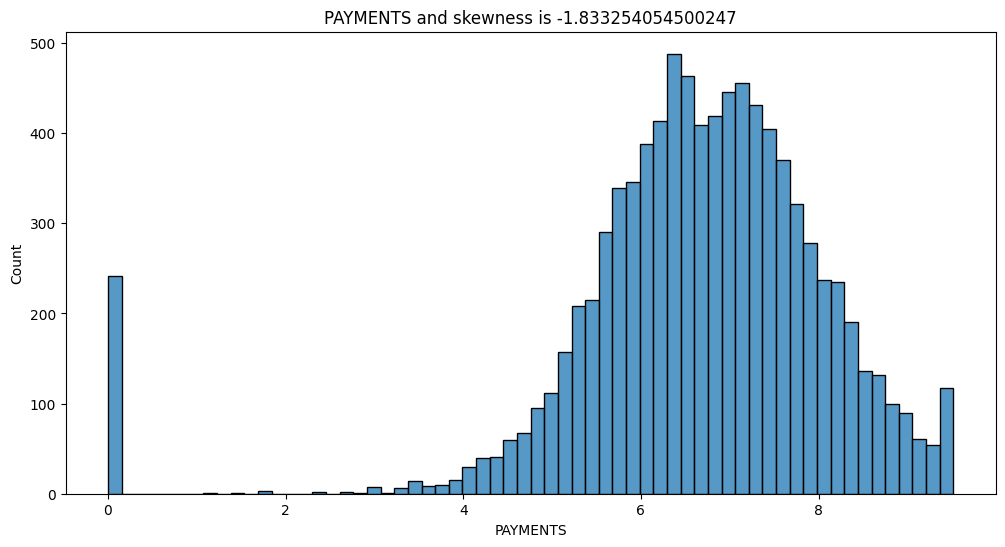

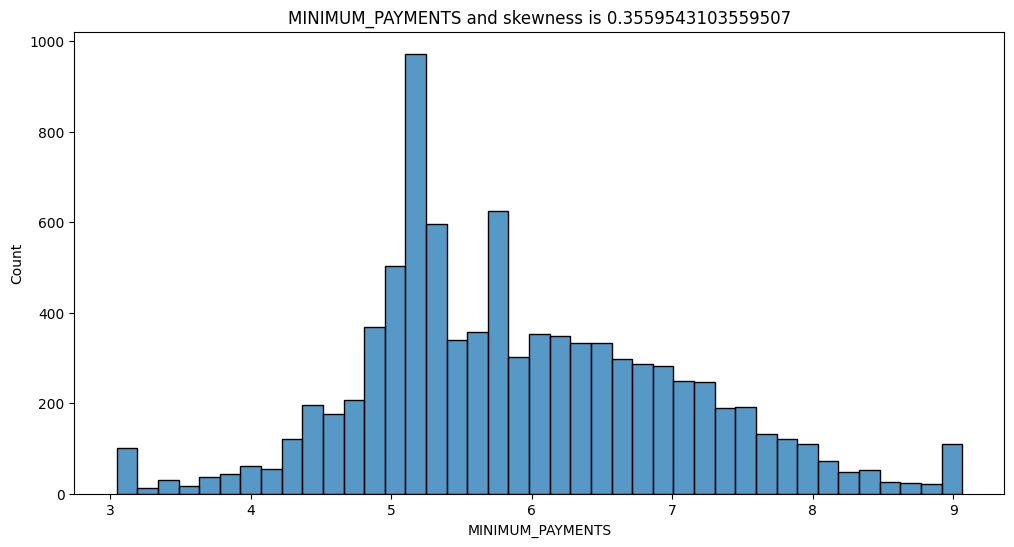

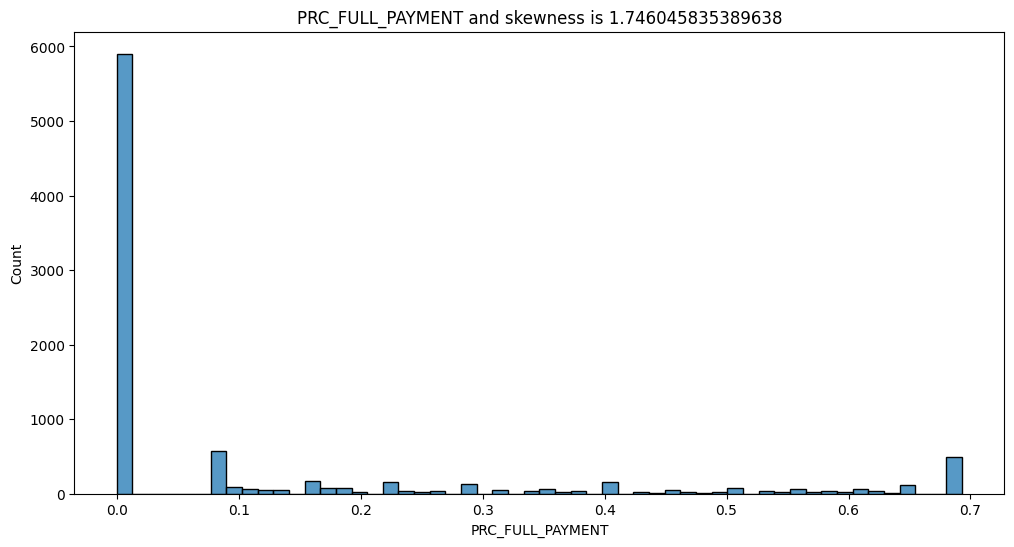

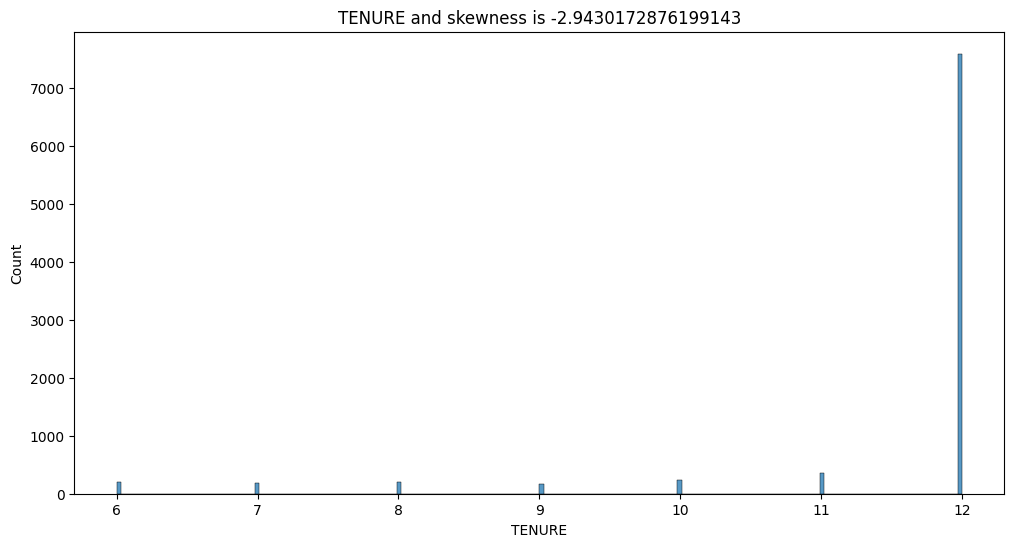

<Axes: xlabel='TENURE', ylabel='Count'>

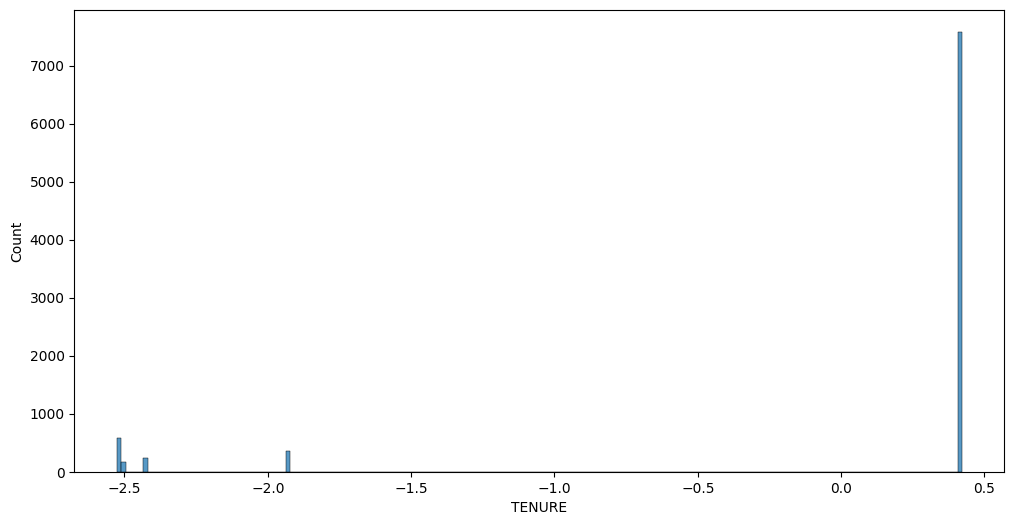

In [126]:
plt.figure(figsize=(12,6))
sns.histplot(data=df3,x='TENURE')


## Robust scaler handle outlier well

In [148]:
x_scaled=RobustScaler().fit_transform(df1)

### again PCA to see whole after the scaled

In [149]:
pca=PCA(n_components=2).fit_transform(x_scaled)
pca_df=pd.DataFrame(data=pca,columns=['pca1','pca2'])


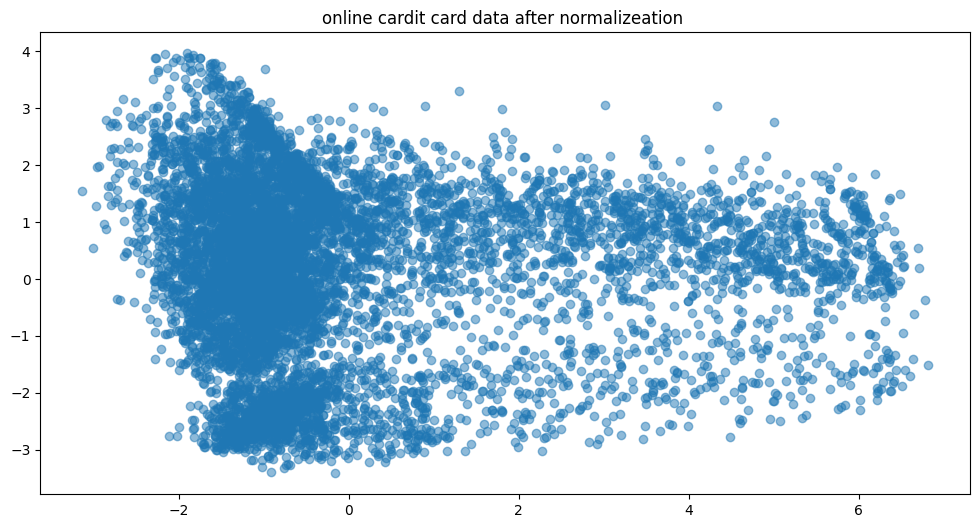

In [150]:
plt.figure(figsize=(12,6))
plt.scatter(data=pca_df,x='pca1',y='pca2',alpha=.5)
plt.title('online cardit card data after normalizeation ')
plt.show()

### now apply kmeans algo with different k values

In [142]:
inertia=[]
K_range=range(2,11)
for k in K_range:
    km=KMeans(n_clusters=k,random_state=42,n_init=10)
    km.fit(x_scaled)
    inertia.append(km.inertia_)


### now apply elbow method to find best k

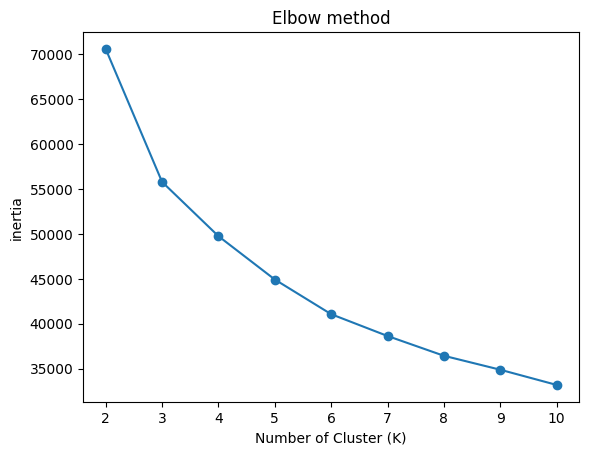

In [143]:
plt.plot(K_range,inertia,marker='o')
plt.xlabel('Number of Cluster (K)')
plt.ylabel('inertia')
plt.title('Elbow method')
plt.show()

In [153]:
silhouette_scores=[]
for k in K_range:
    km=KMeans(n_clusters=k,random_state=32,n_init=10)
    labels=km.fit_predict(x_scaled)
    score=silhouette_score(x_scaled,labels)
    silhouette_scores.append(score)
    inertia.append(km.inertia_)
    print(f'K={k} and silhoette score{score:.4f}')

K=2 and silhoette score0.3677
K=3 and silhoette score0.2573
K=4 and silhoette score0.2242
K=5 and silhoette score0.2347
K=6 and silhoette score0.2313
K=7 and silhoette score0.2158
K=8 and silhoette score0.2160
K=9 and silhoette score0.2258
K=10 and silhoette score0.2303


## silhoette score show the best k value so k=2 is best

In [154]:
df1['labels']=KMeans(n_clusters=2,random_state=42,n_init=10).fit_predict(x_scaled)

In [156]:
pca_df['labels']=df1['labels']

### plot the data and see the clusters 

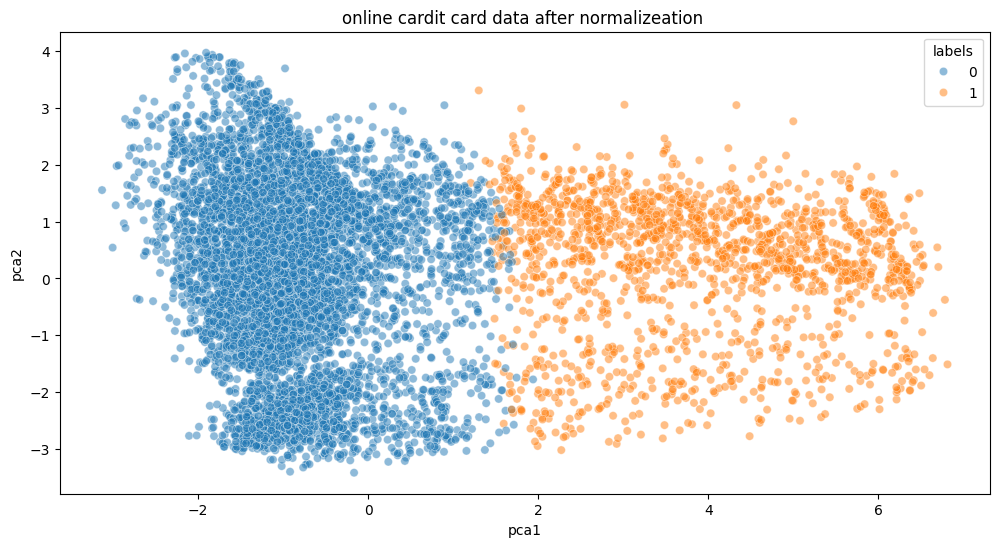

In [157]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=pca_df,x='pca1',y='pca2',hue='labels',alpha=.5)
plt.title('online cardit card data after normalizeation ')
plt.show()

In [159]:
df1.groupby('labels').mean()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
labels,,,,,,,,,,,,,,,,,
0,6.732549,0.704000,5.00866,3.410845,3.486934,3.613120,0.530225,0.326491,0.394517,0.266694,0.910005,3.086477,8.130860,36.231407,6.145265,0.189908,0.042416
1,3.556971,0.942255,4.38149,2.239326,2.718147,1.962161,0.309168,0.166286,0.227758,0.114697,0.375915,1.818554,7.936925,25.803991,4.883202,0.304060,-0.193056
